In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
account_transactions = pd.read_csv(r"E:\Retail Banking\cleaned_data\account_transactions_Cleaned.csv")
bank_accounts = pd.read_csv(r"E:\Retail Banking\cleaned_data\bank_accounts_Cleaned.csv")
customer_profiles = pd.read_csv(r"E:\Retail Banking\cleaned_data\customer_profiles_Cleaned.csv")
transaction_codes = pd.read_csv(r"E:\Retail Banking\cleaned_data\transaction_codes_Cleaned.csv")

In [13]:
account_transactions['created_time'] = pd.to_datetime(account_transactions['created_time'])
bank_accounts['creation_date'] = pd.to_datetime(bank_accounts['creation_date'])
bank_accounts['term_months'] = bank_accounts['term_months'].astype('Int64')
customer_profiles['birth_date'] = pd.to_datetime(customer_profiles['birth_date'])

### Univariate Analysis

#### Numerical Columns

In [4]:
datasets = {
    'account_transactions' : account_transactions,
    'bank_accounts' : bank_accounts,
    'customer_profiles' : customer_profiles,
    'transaction_codes' : transaction_codes
}
for name, df in datasets.items():
    numeric_columns = df.select_dtypes(include=np.number).columns

    for col in numeric_columns:
        summary = df[[col]].describe().T
        summary['median'] = df[col].median()
        summary['IQR'] = summary['75%'] - summary['25%']
        summary['skewness'] = df[col].skew()
        print("Numeric Summary Statistics:\n")
        print(f"\n{name.upper()}-{col}")
        display(summary)

Numeric Summary Statistics:


ACCOUNT_TRANSACTIONS-amount


,count,mean,std,min,25%,50%,75%,max,median,IQR,skewness
amount,2377169.0,911.080931,6559.544615,0.36,69.23,200.0,620.0,1214710.19,200.0,550.77,58.600042


Numeric Summary Statistics:


BANK_ACCOUNTS-balance


,count,mean,std,min,25%,50%,75%,max,median,IQR,skewness
balance,3553.0,93478.386946,167399.756136,0.0,0.0,20677.89,93213.9,1693797.02,20677.89,93213.9,3.002544


Numeric Summary Statistics:


BANK_ACCOUNTS-loan_amount


,count,mean,std,min,25%,50%,75%,max,median,IQR,skewness
loan_amount,1007.0,76234.810278,142773.596051,1058.14,12471.08,22844.58,49898.885,798422.53,22844.58,37427.805,3.023144


Numeric Summary Statistics:


BANK_ACCOUNTS-term_months


,count,mean,std,min,25%,50%,75%,max,median,IQR,skewness
term_months,2553.0,23.609871,17.118381,3.0,12.0,24.0,36.0,60.0,24.0,24.0,0.626769


Numeric Summary Statistics:


BANK_ACCOUNTS-interest_rate


,count,mean,std,min,25%,50%,75%,max,median,IQR,skewness
interest_rate,2553.0,8.704857,6.471451,0.5,4.5,5.0,13.4,24.0,5.0,8.9,1.009722


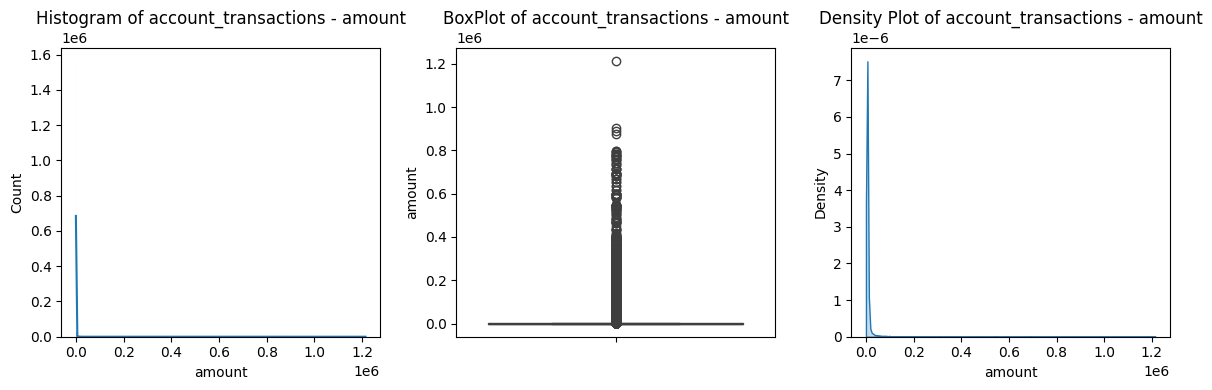

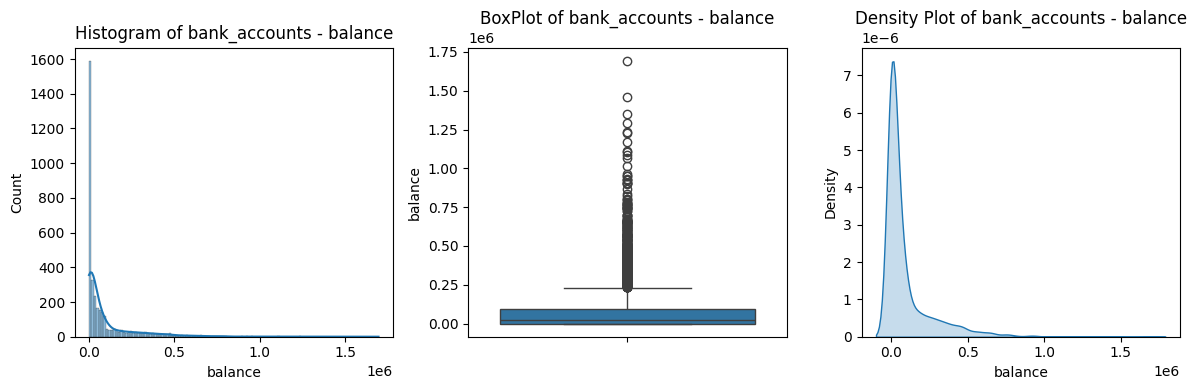

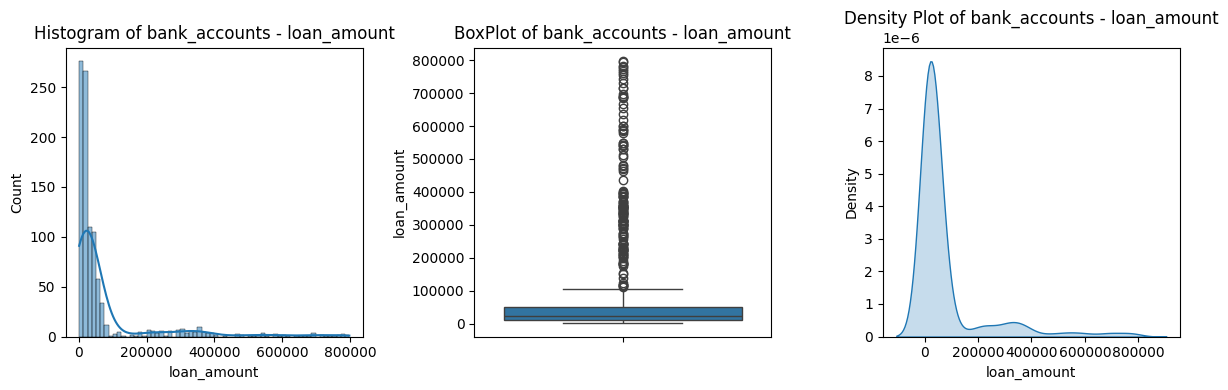

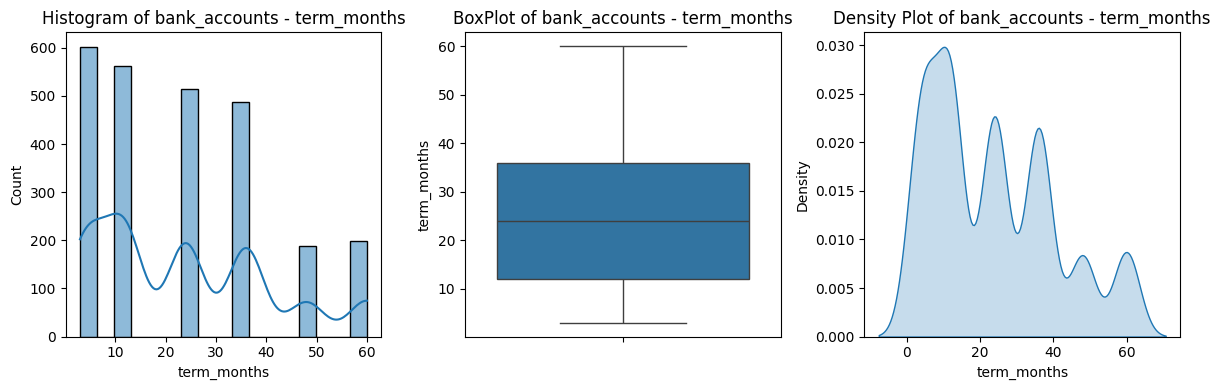

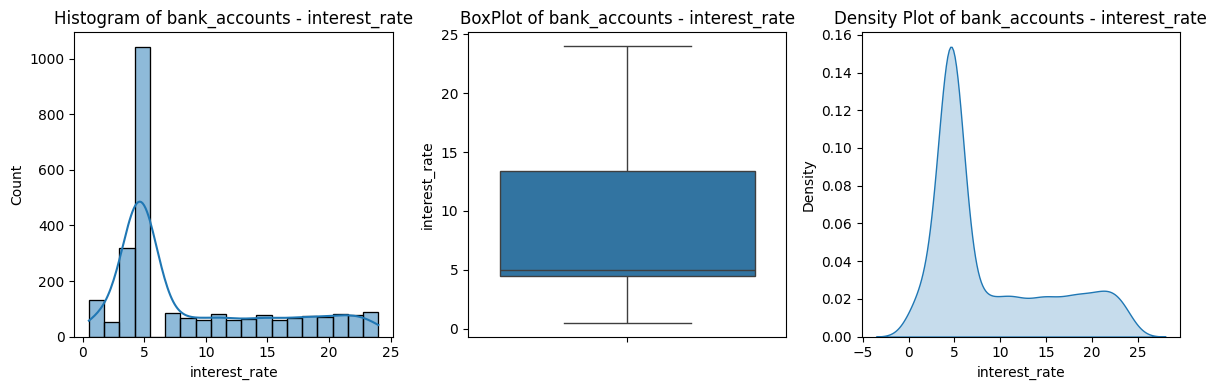

In [5]:
datasets = {
    'account_transactions' : account_transactions,
    'bank_accounts' : bank_accounts,
    'customer_profiles' : customer_profiles,
    'transaction_codes' : transaction_codes
}
for name, df in datasets.items():
    numeric_columns = df.select_dtypes(include=np.number).columns

    for col in numeric_columns:
        plt.figure(figsize = (12, 4))

        plt.subplot(1, 3, 1)
        sns.histplot(df[col], kde=True)
        plt.title(f'Histogram of {name} - {col}')

        plt.subplot(1, 3, 2)
        sns.boxplot(df[col], fill = True)
        plt.title(f'BoxPlot of {name} - {col}')

        plt.subplot(1, 3, 3)
        sns.kdeplot(df[col], fill = True)
        plt.title(f'Density Plot of {name} - {col}')

        plt.tight_layout()
        plt.show()

#### Categorical Columns

Frequency count for ACCOUNT_TRANSACTIONS - transaction_type transaction_type
Debit     1766298
Credit     610871
Name: count, dtype: int64


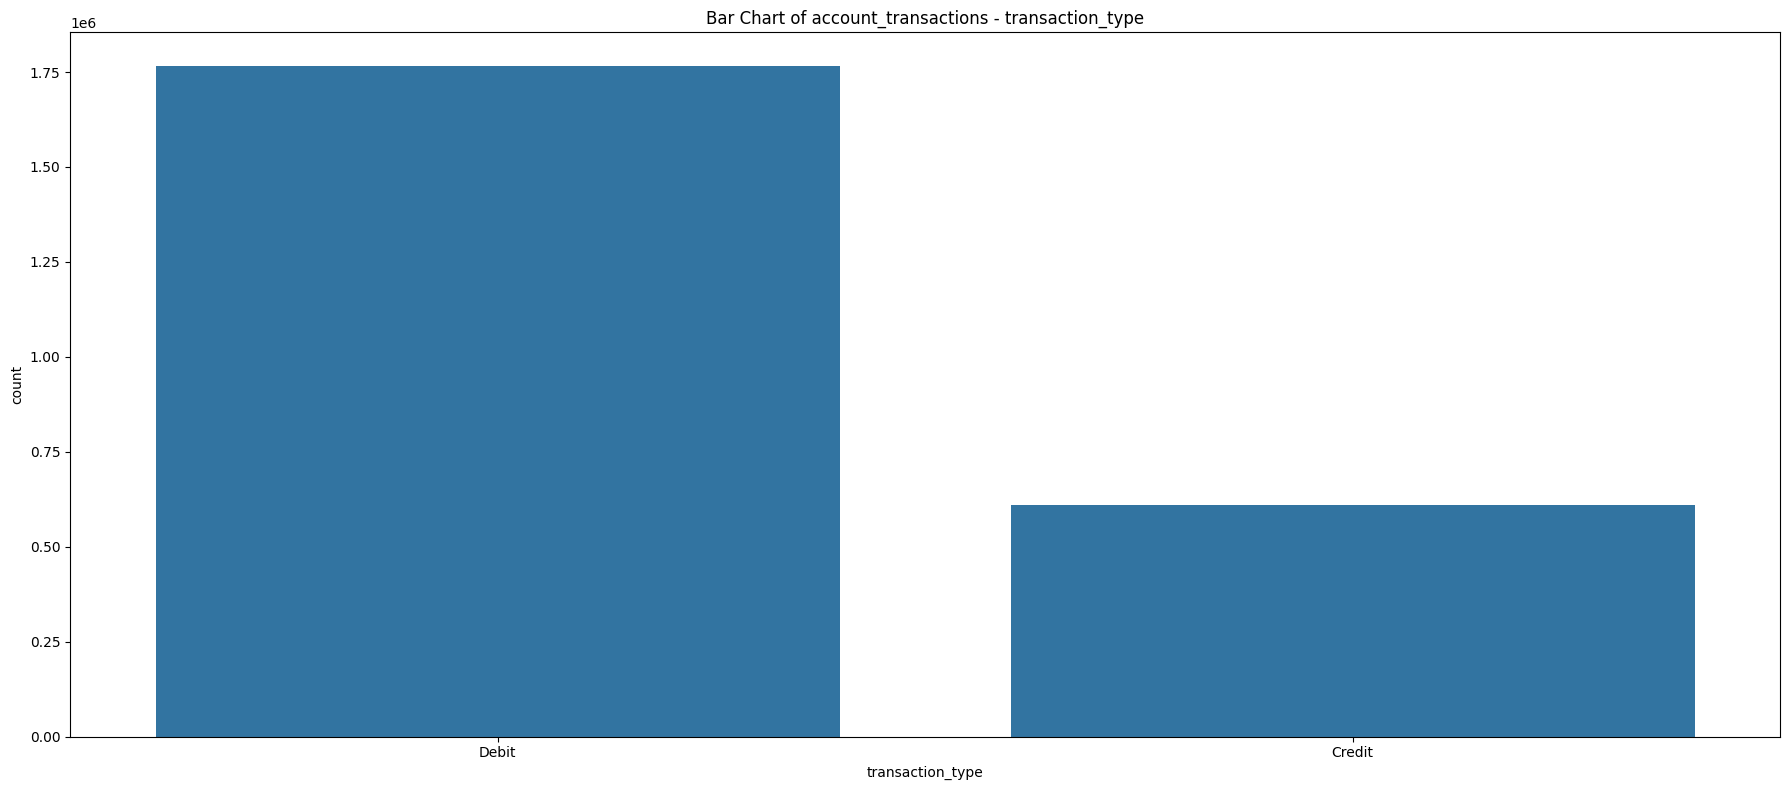

Frequency count for ACCOUNT_TRANSACTIONS - transaction_code transaction_code
MER_PAY       983952
CSH_WDL       490430
CSH_DEP       371234
IBK_OUT       240805
IBK_IN        235232
LN_PMNT        15274
LN_PMNT_DR     15274
LN_INT_CHG     15274
SYS_FEE         3432
FD_OPEN         1546
FD_OPEN_DR      1012
LN_DISB         1007
LN_DISB_CR      1007
FD_MAT_CHG       845
FD_MAT_CR        845
Name: count, dtype: int64


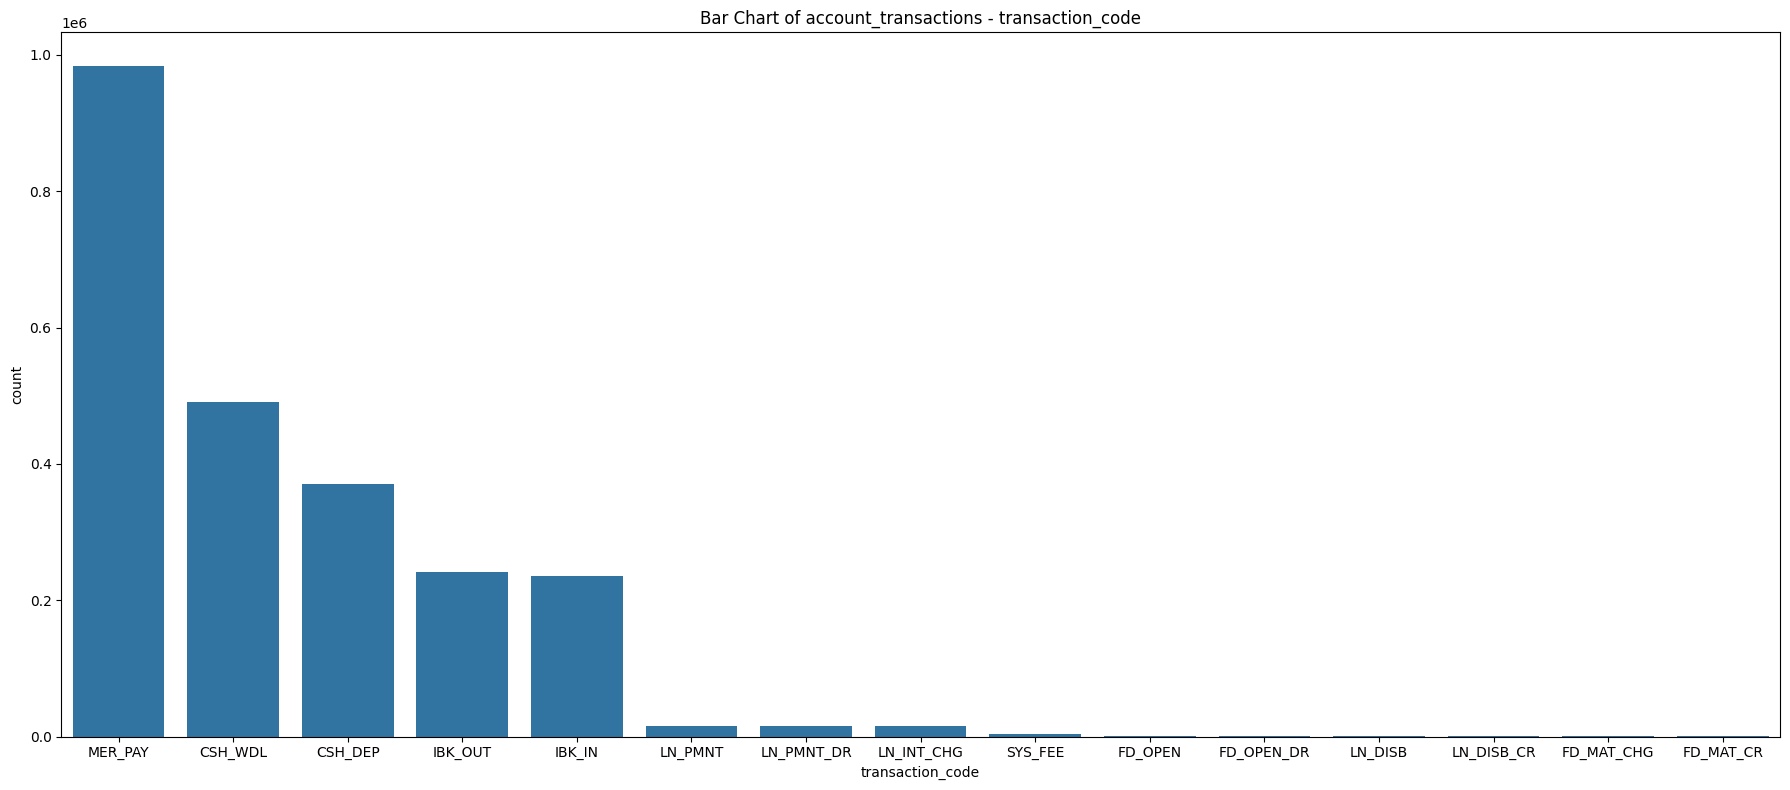

Frequency count for ACCOUNT_TRANSACTIONS - channel channel
OnlineBanking      491988
MobileApp          491964
InterbankPortal    476037
Branch             465789
ATM                430995
System              20396
Name: count, dtype: int64


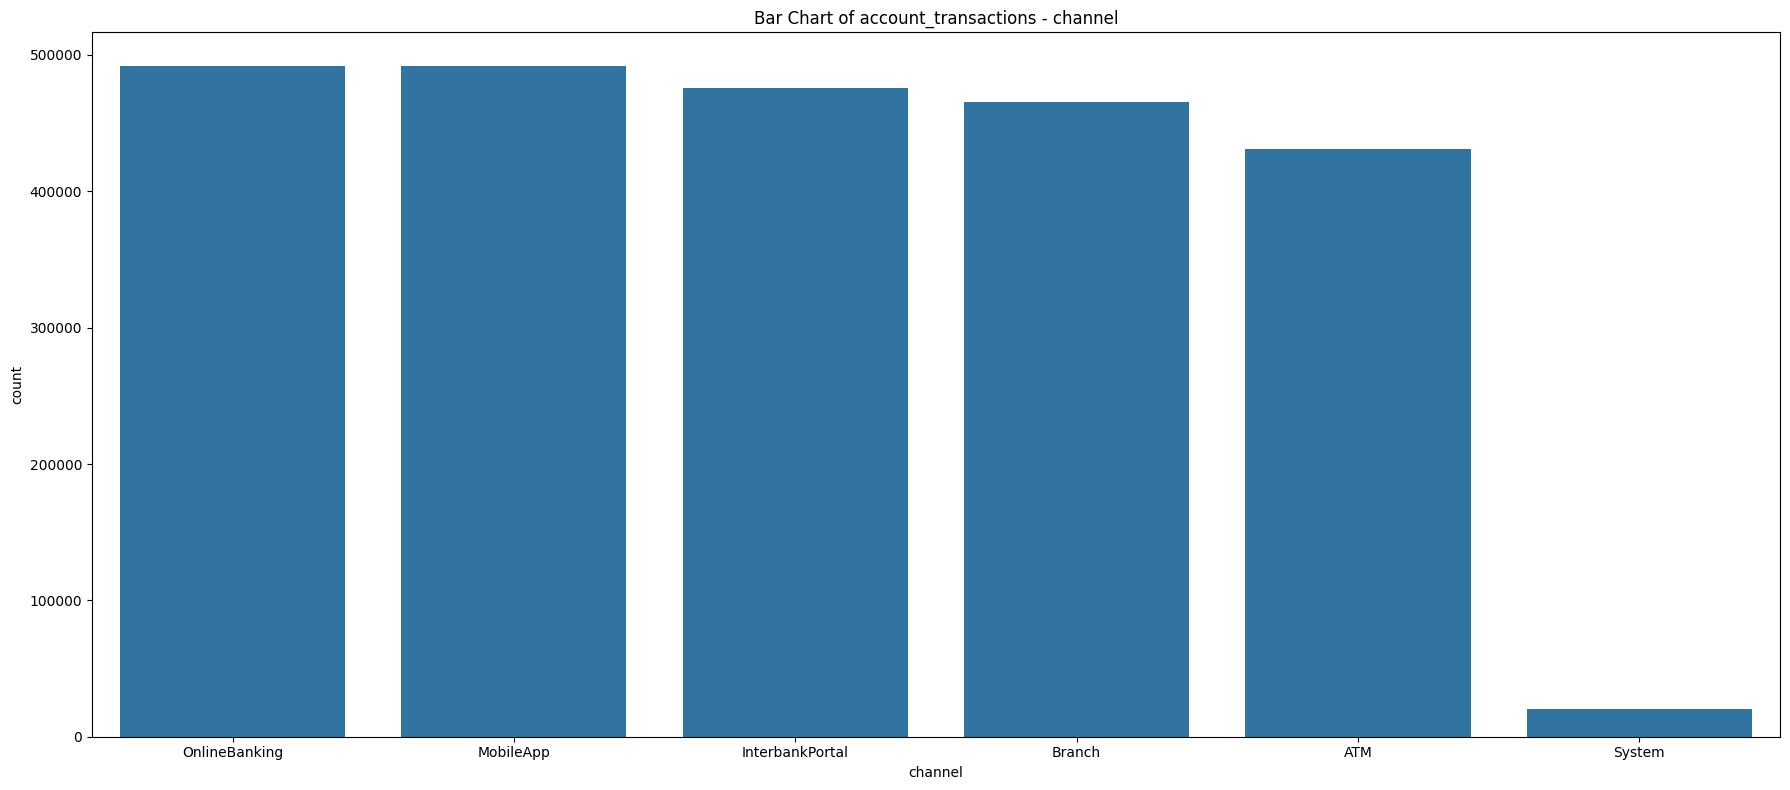

Frequency count for BANK_ACCOUNTS - account_type account_type
FixedDeposit    1546
Loan            1007
Savings         1000
Name: count, dtype: int64


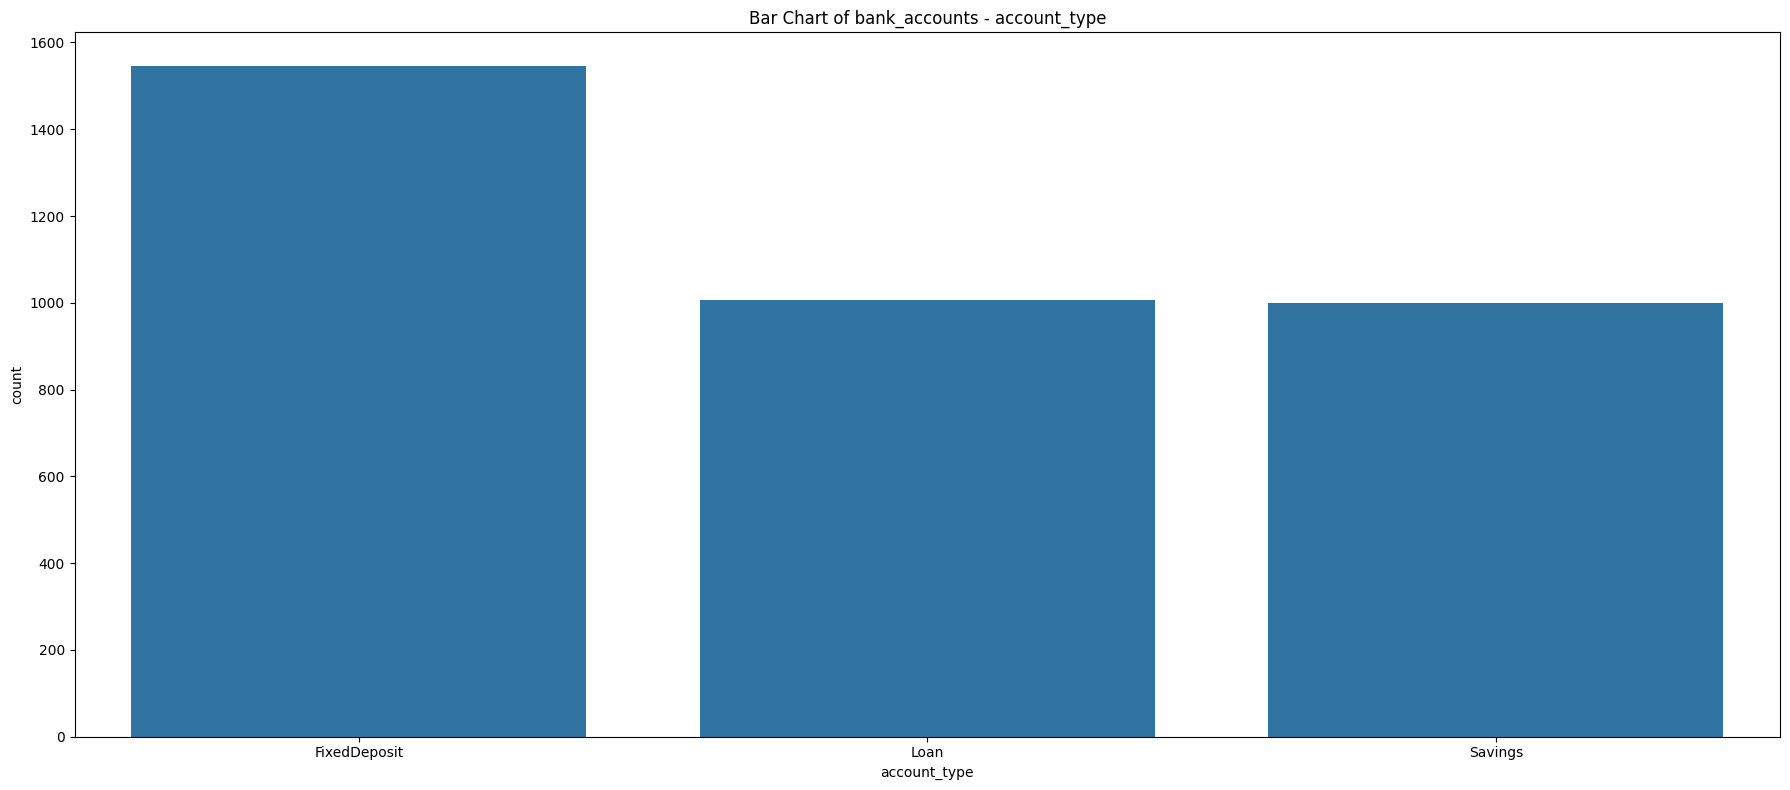

Frequency count for BANK_ACCOUNTS - account_status account_status
Active      2484
Inactive    1069
Name: count, dtype: int64


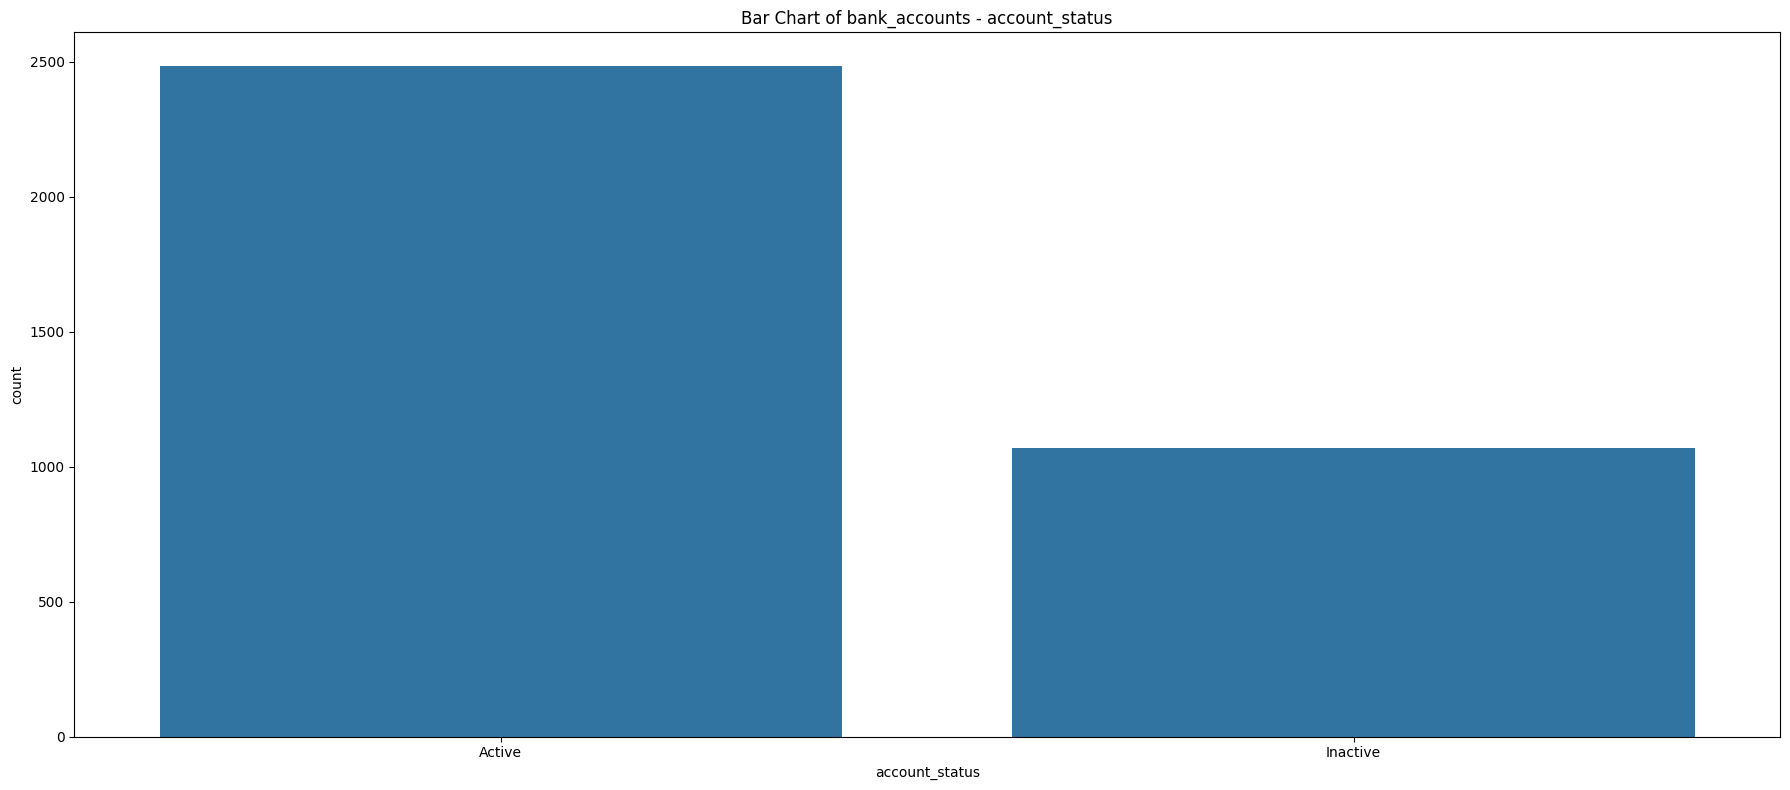

Frequency count for CUSTOMER_PROFILES - city city
San Diego          52
Sacramento         46
San Francisco      45
Los Angeles        43
San Antonio        36
                   ..
Carmel              1
Racine              1
Arlington           1
North Las Vegas     1
Fort Wayne          1
Name: count, Length: 94, dtype: int64


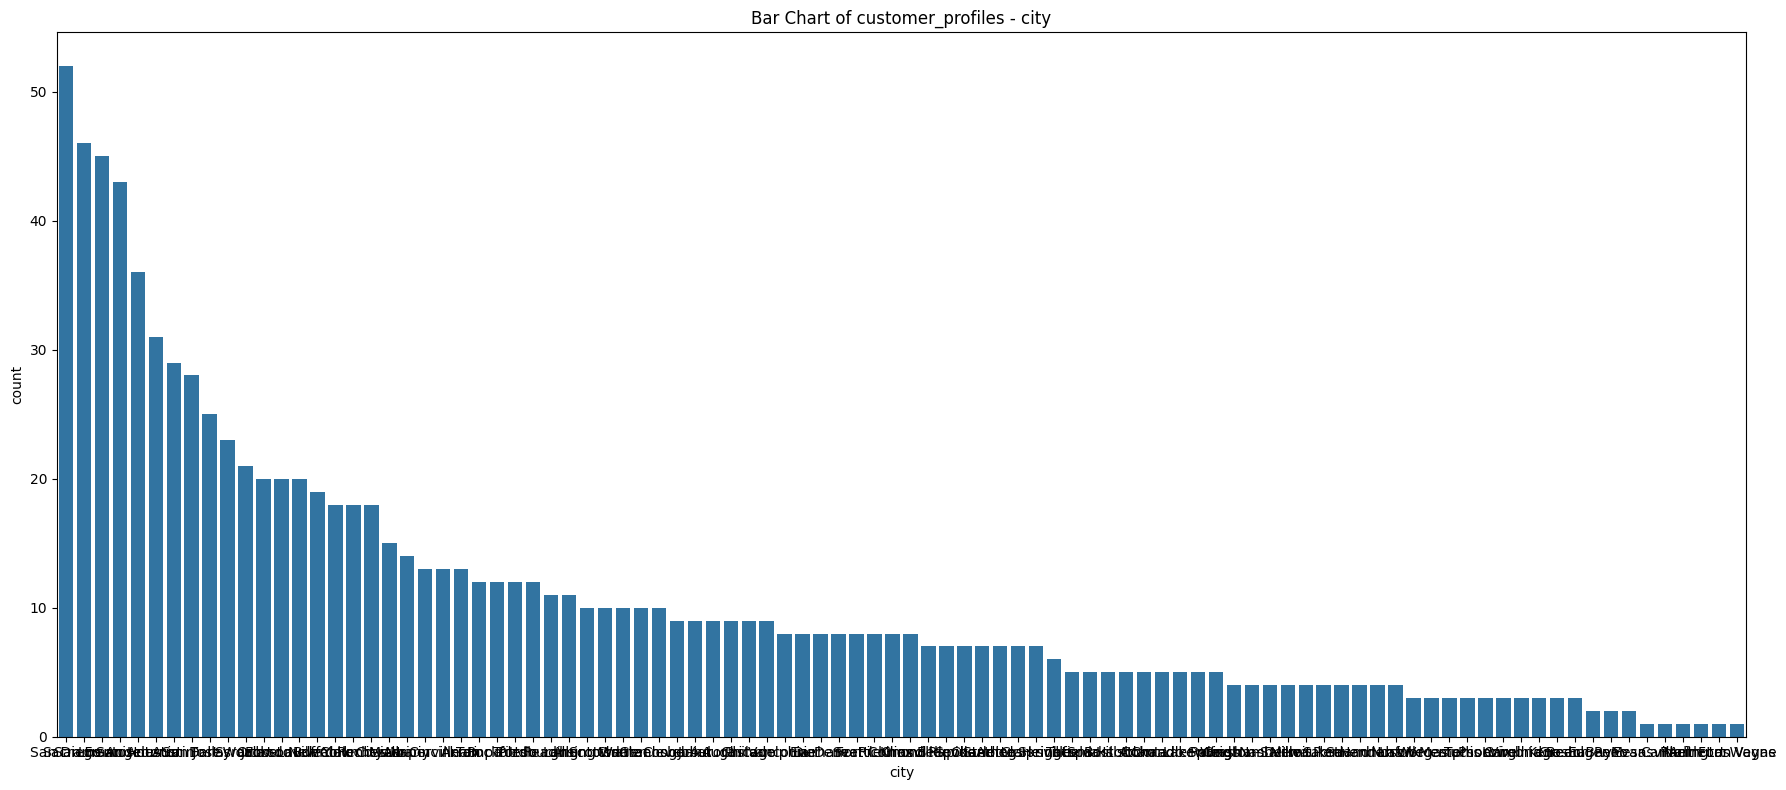

Frequency count for CUSTOMER_PROFILES - state state
California        214
Texas             144
New York           90
Florida            87
Ohio               55
Pennsylvania       50
Illinois           49
Michigan           39
Washington         35
Georgia            35
North Carolina     34
Tennessee          32
Colorado           29
Arizona            23
Massachusetts      20
Oregon             19
Virginia           16
Nevada             15
Wisconsin          11
Indiana             3
Name: count, dtype: int64


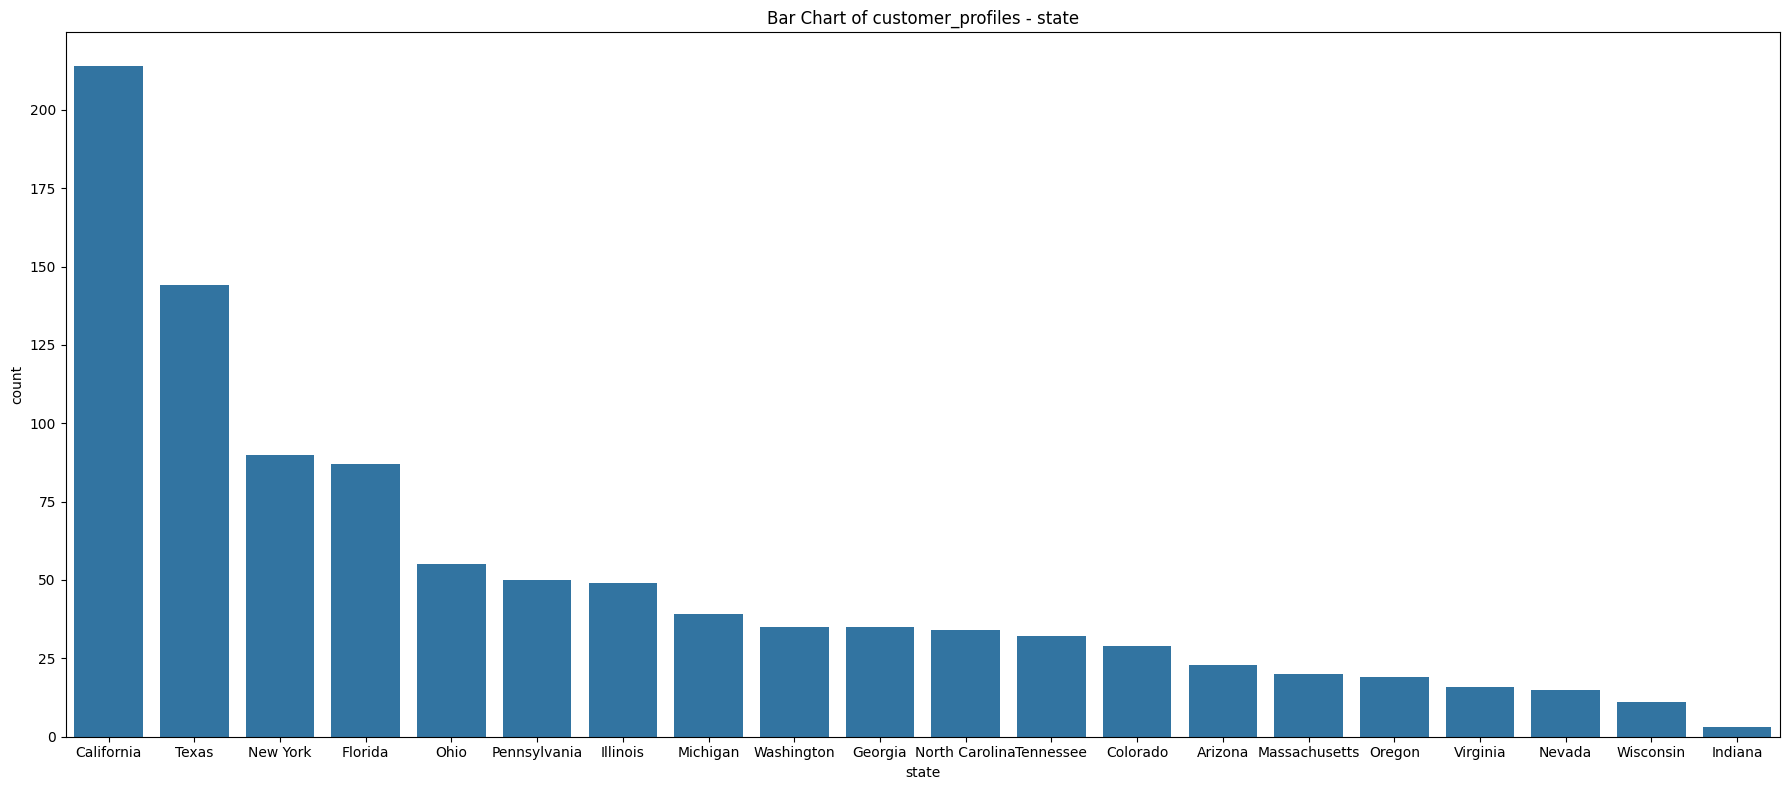

Frequency count for TRANSACTION_CODES - transaction_code transaction_code
MER_PAY       1
CSH_WDL       1
CSH_DEP       1
IBK_OUT       1
IBK_IN        1
SYS_FEE       1
LN_DISB       1
LN_DISB_CR    1
LN_PMNT       1
LN_PMNT_DR    1
LN_INT_CHG    1
FD_OPEN       1
FD_OPEN_DR    1
FD_MAT_CHG    1
FD_MAT_CR     1
Name: count, dtype: int64


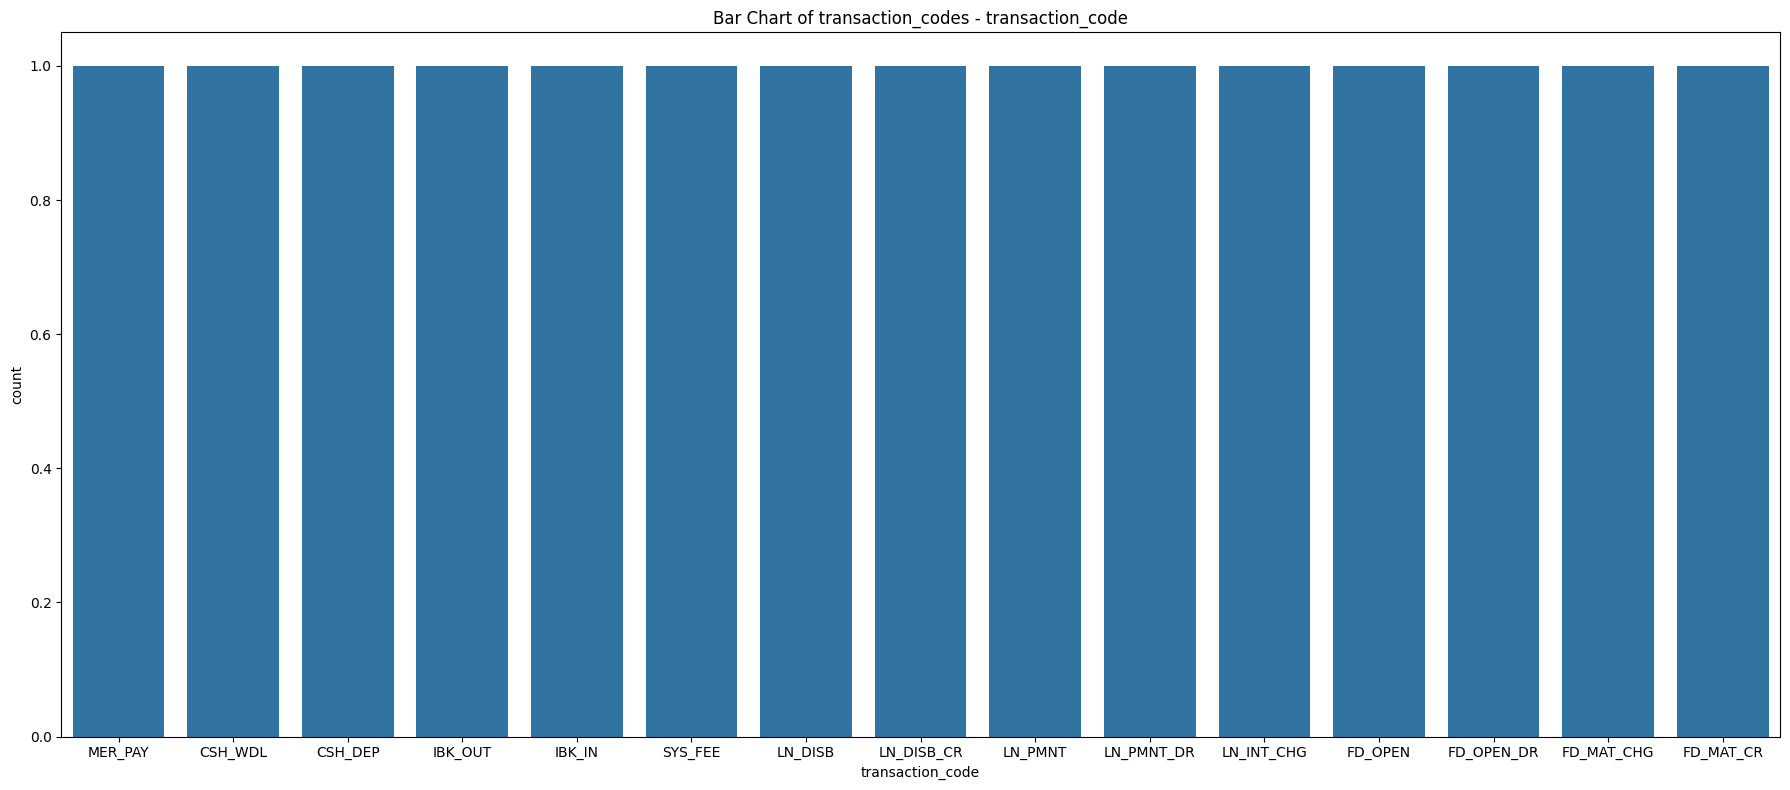

Frequency count for TRANSACTION_CODES - label label
Merchant Payment            1
Cash Withdrawal             1
Cash Deposit                1
Interbank Transfer Out      1
Interbank Transfer In       1
Annual Maintenance Fee      1
Loan Disbursement           1
Loan Disbursement Credit    1
Loan Repayment              1
Loan Repayment Debit        1
Loan Interest Charge        1
FD Opening Credit           1
FD Opening Debit            1
FD Maturity Liquidation     1
FD Maturity Credit          1
Name: count, dtype: int64


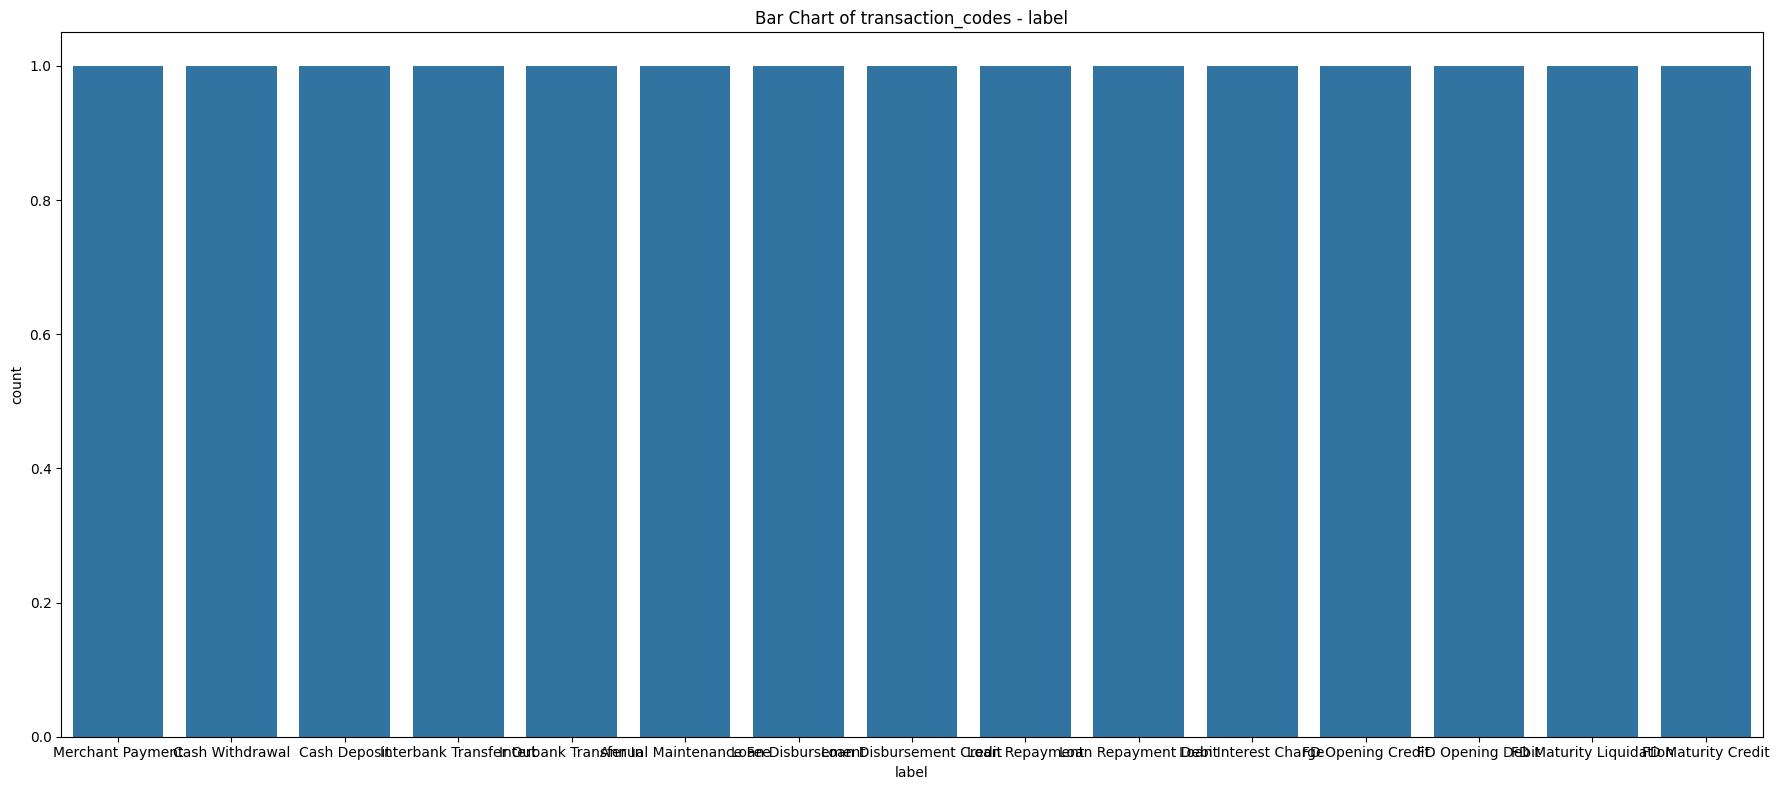

Frequency count for TRANSACTION_CODES - account_type account_type
Savings         10
Loan             3
FixedDeposit     2
Name: count, dtype: int64


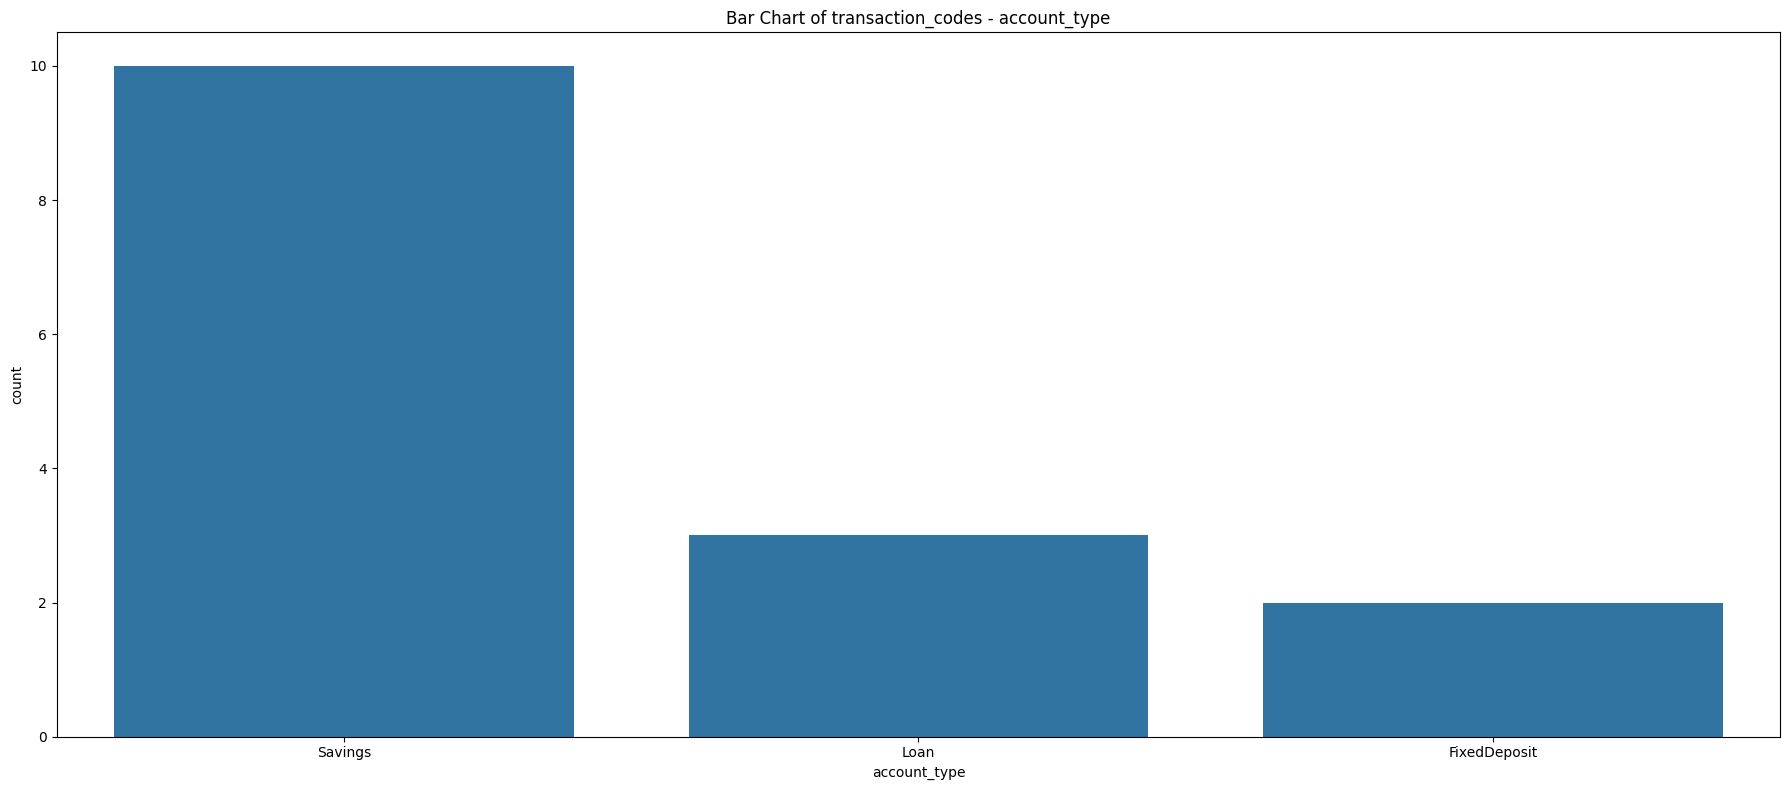

Frequency count for TRANSACTION_CODES - transaction_type transaction_type
Debit     9
Credit    6
Name: count, dtype: int64


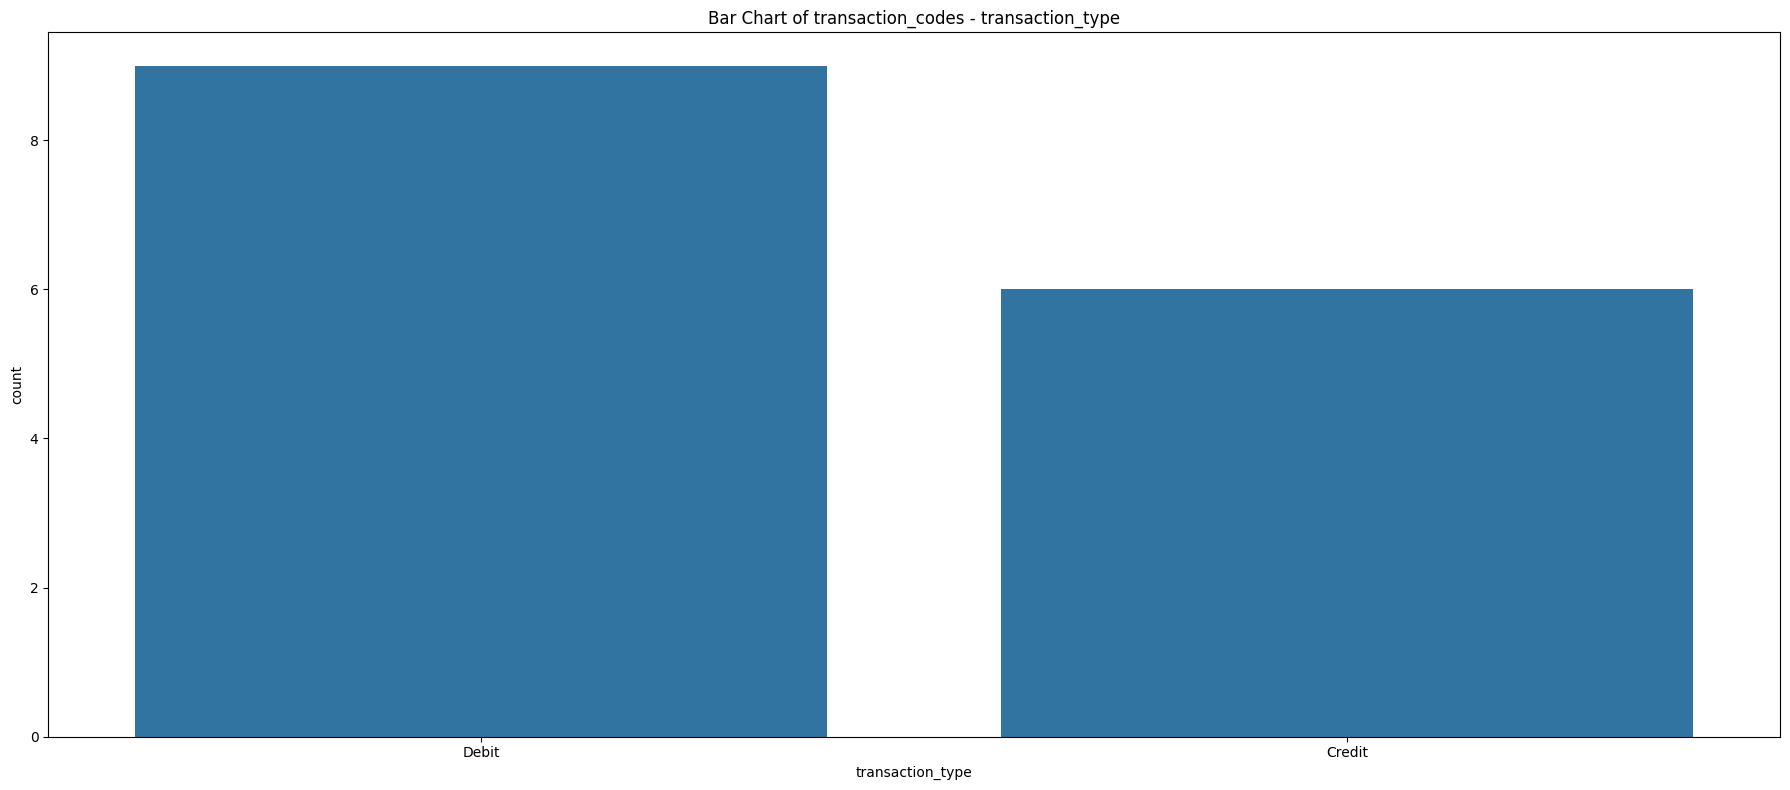

Frequency count for TRANSACTION_CODES - channel channel
Branch                     6
System                     4
ATM,Branch                 2
InterbankPortal            2
MobileApp,OnlineBanking    1
Name: count, dtype: int64


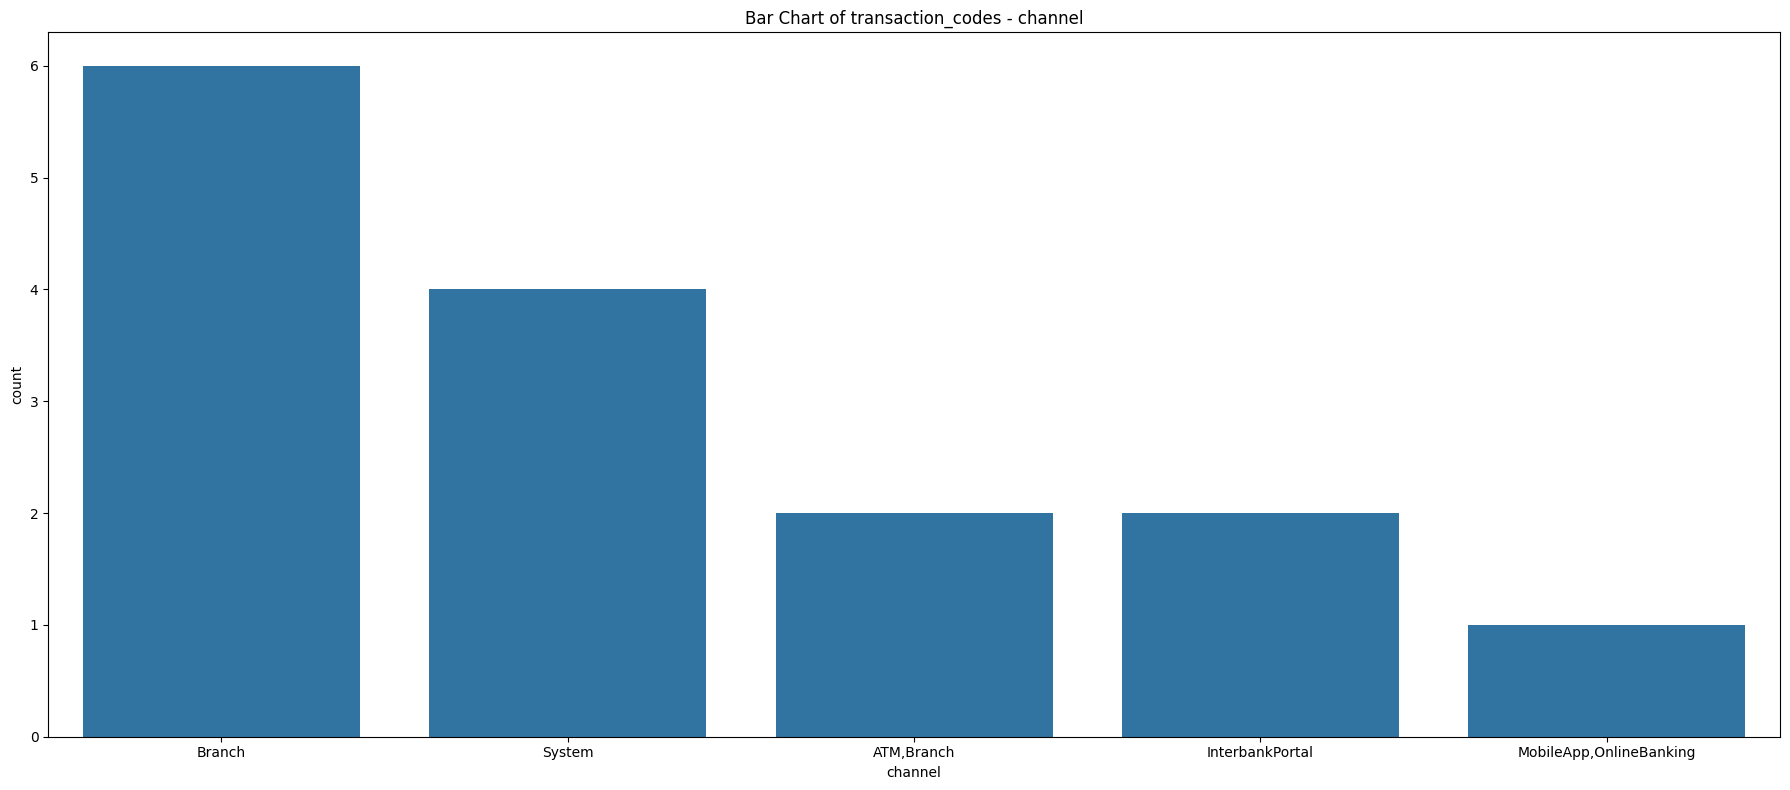

In [6]:
datasets = {
    'account_transactions' : account_transactions,
    'bank_accounts' : bank_accounts,
    'customer_profiles' : customer_profiles,
    'transaction_codes' : transaction_codes
}
for name, df in datasets.items():
    categorical_columns = df.select_dtypes(include = str).columns

    for col in categorical_columns:
        if 'id' in col.lower():
            continue

        print(f'Frequency count for {name.upper()} - {col}', df[col].value_counts())
        plt.figure(figsize=(18, 8))
        sns.countplot(x = col, data=df, order = df[col].value_counts().index)
        plt.title(f'Bar Chart of {name} - {col}')
        plt.tight_layout()
        plt.show()

#### DateTime Columns

Date Range for account_transactions - created_time: 2020-01-02 10:27:00 to 2025-12-31 21:01:00
Time Span: 2190 days


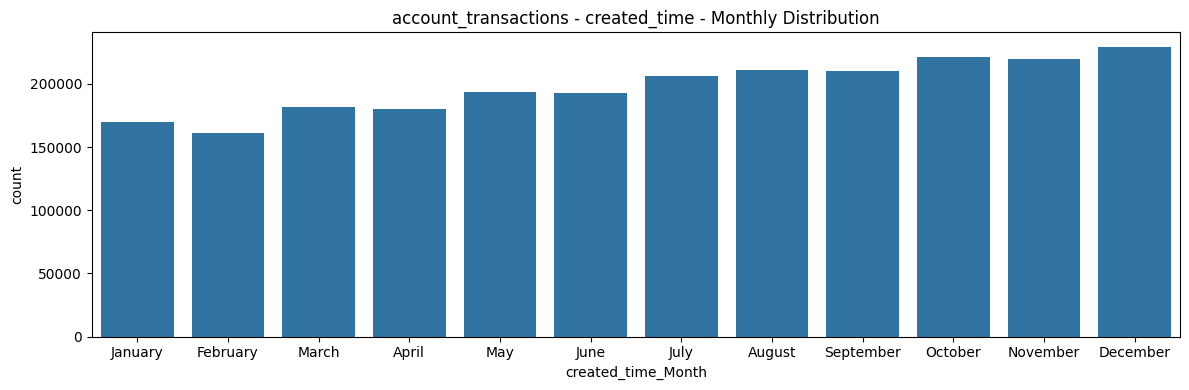

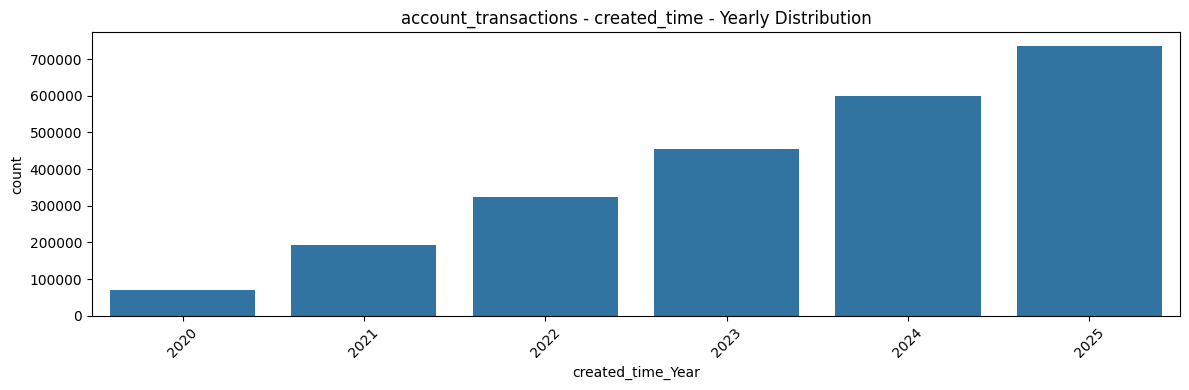

Date Range for bank_accounts - creation_date: 2020-01-02 00:00:00 to 2025-12-01 00:00:00
Time Span: 2160 days


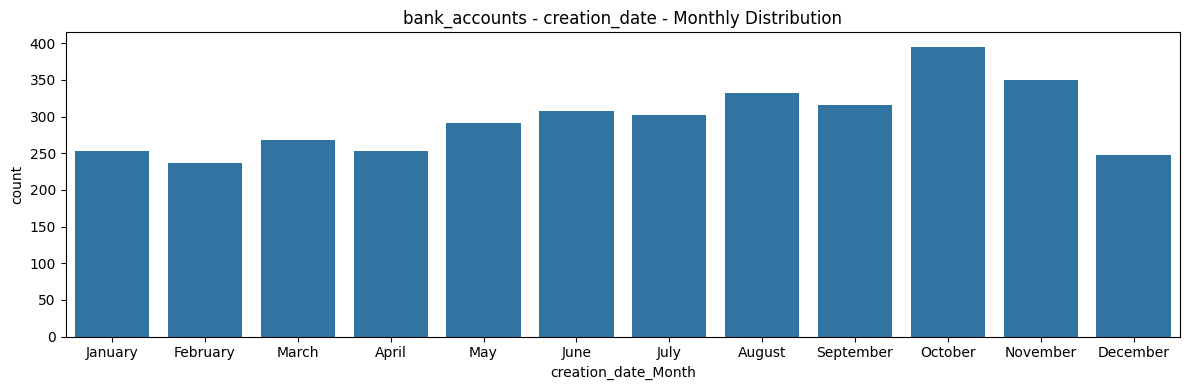

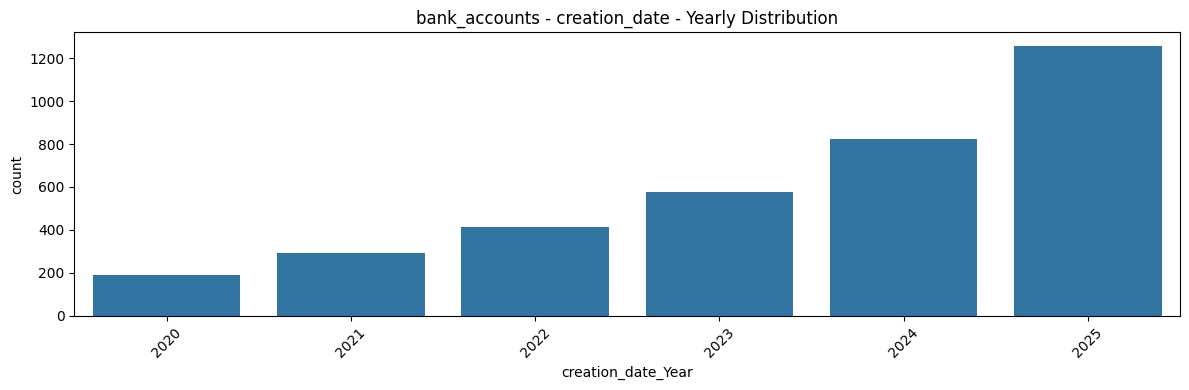

Date Range for customer_profiles - birth_date: 1950-07-27 00:00:00 to 2008-05-15 00:00:00
Time Span: 21112 days


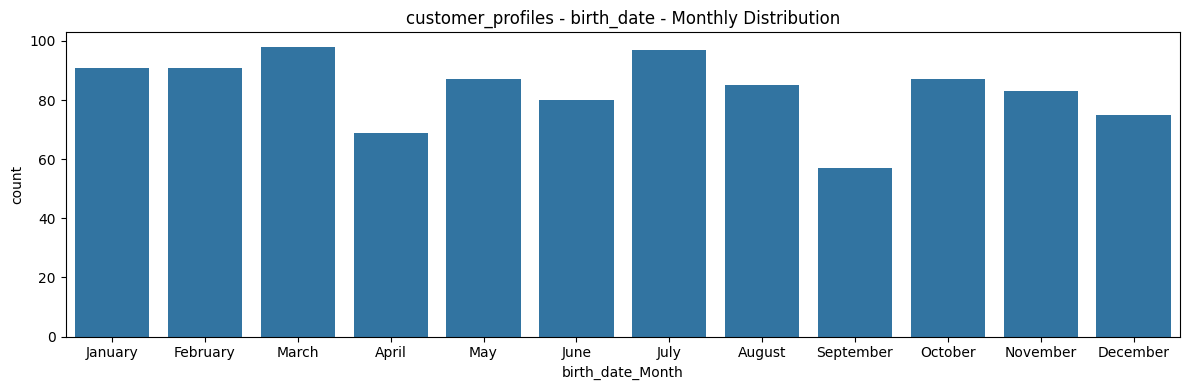

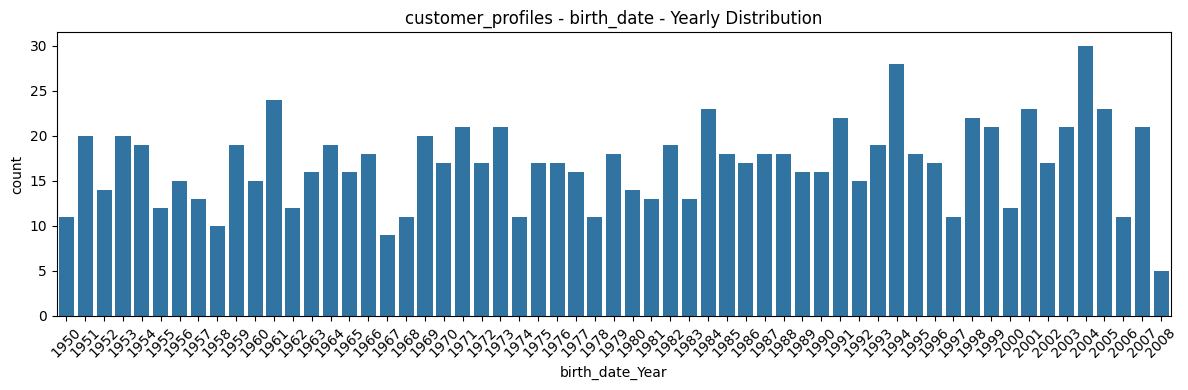

In [7]:
datasets = {
    'account_transactions' : account_transactions,
    'bank_accounts' : bank_accounts,
    'customer_profiles' : customer_profiles,
    'transaction_codes' : transaction_codes
}
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
for name, df in datasets.items():
    datetime_columns = df.select_dtypes(include='datetime64').columns

    if len(datetime_columns) == 0:
        continue

    for col in datetime_columns:
        print(f'Date Range for {name} - {col}: {df[col].min()} to {df[col].max()}')
        print(f'Time Span: {(df[col].max() - df[col].min()).days} days')

        month_col = col + '_Month'
        df[month_col] = df[col].dt.month_name()

        year_col = col + '_Year'
        df[year_col] = df[col].dt.year

        plt.figure(figsize = (12, 4))
        sns.countplot(x = month_col, data = df, order = months)
        plt.title(f'{name} - {col} - Monthly Distribution')

        plt.tight_layout()
        plt.show()

        plt.figure(figsize = (12, 4))
        sns.countplot(x = year_col, data = df)
        plt.title(f'{name} - {col} - Yearly Distribution')
        plt.xticks(rotation = 45)

        plt.tight_layout()
        plt.show()

In [8]:
account_transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 2377169 entries, 0 to 2377168
Data columns (total 10 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   transaction_id         str           
 1   account_id             str           
 2   linked_transaction_id  str           
 3   created_time           datetime64[us]
 4   transaction_type       str           
 5   transaction_code       str           
 6   amount                 float64       
 7   channel                str           
 8   created_time_Month     str           
 9   created_time_Year      int32         
dtypes: datetime64[us](1), float64(1), int32(1), str(7)
memory usage: 399.9 MB


C:\Users\HAMAAD NASIR\AppData\Local\Temp\ipykernel_9800\1903004611.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  account_transactions['created_time_Month'] = pd.to_datetime(account_transactions['created_time_Month'])


<Figure size 1200x800 with 0 Axes>

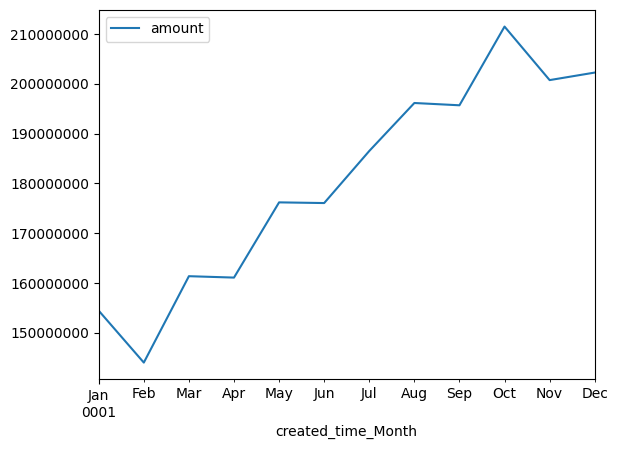

In [9]:
account_transactions['created_time_Month'] = pd.to_datetime(account_transactions['created_time_Month'])

plt.figure(figsize=(12, 8))
account_transactions.groupby('created_time_Month')[['amount']].sum().plot()
plt.ticklabel_format(style='plain', axis = 'y')
plt.show()

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose
account_transactions['created_time'] = account_transactions['created_time'].dt.date
transaction_daily = account_transactions.groupby('created_time')[['amount']].sum()
result = seasonal_decompose(transaction_daily, model = 'addictive', period=30)


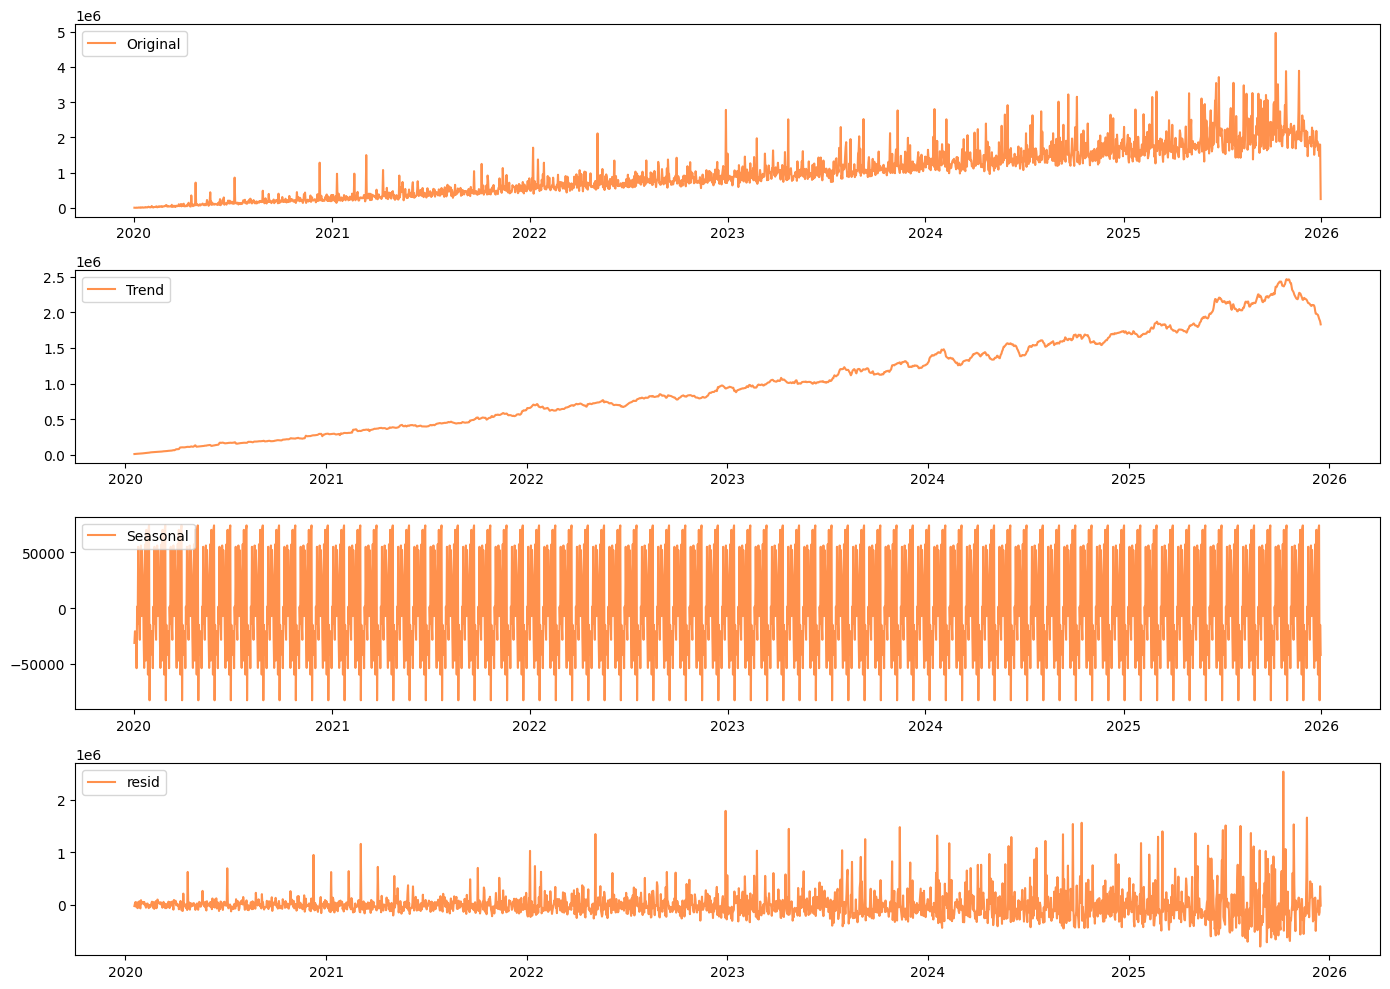

In [11]:
trend_additive = result.trend
seasonal_additive = result.seasonal
residual_additive = result.resid

plt.figure(figsize=(14, 10))
plt.subplot(411)
plt.plot(transaction_daily, label = 'Original', color = '#FF914D')
plt.legend(loc = 'upper left')
plt.subplot(412)
plt.plot(trend_additive, label = 'Trend', color = '#FF914D')
plt.legend(loc = 'upper left')
plt.subplot(413)
plt.plot(seasonal_additive, label = 'Seasonal', color = '#FF914D')
plt.legend(loc = 'upper left')
plt.subplot(414)
plt.plot(residual_additive, label = 'resid', color = '#FF914D')
plt.legend(loc = 'upper left')
plt.tight_layout()
plt.show()

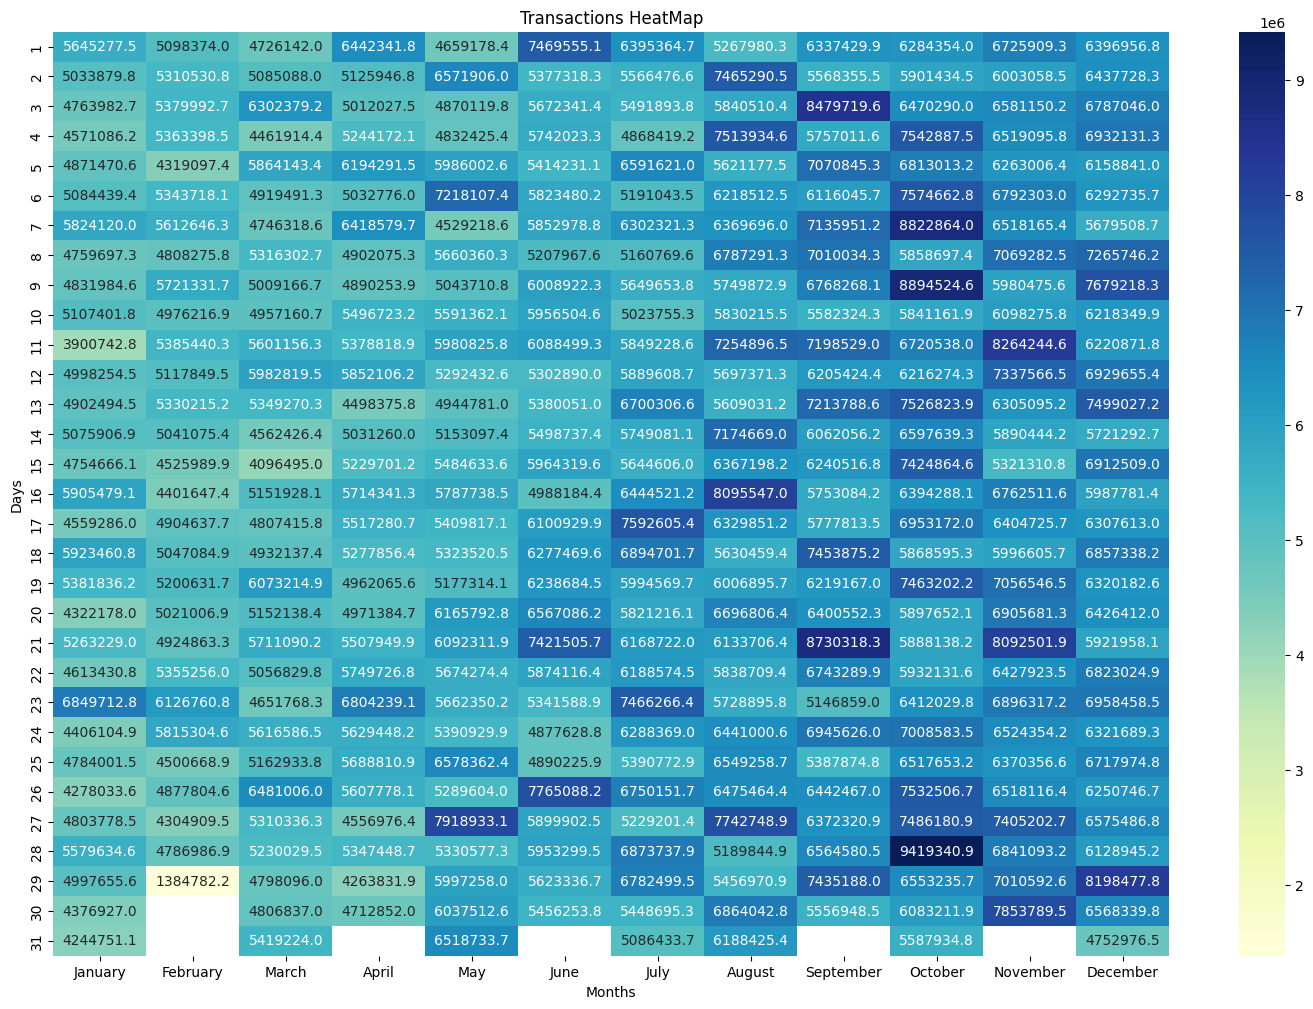

In [14]:
account_transactions['created_time_day'] = account_transactions['created_time'].dt.day

heatmap = account_transactions.pivot_table(
    index = 'created_time_day',
    columns = 'created_time_Month',
    values = 'amount',
    aggfunc = 'sum'
)
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
heatmap = heatmap.reindex(columns=months)
plt.figure(figsize=(18, 12))
sns.heatmap(heatmap, cmap='YlGnBu', annot=True, fmt=".1f")
plt.xlabel("Months")
plt.ylabel("Days")
plt.title("Transactions HeatMap")
plt.show()

### Bivariate Analysis

#### Categorical - Numerical Column

In [15]:
acctransc_cat = account_transactions[['account_id', 'transaction_type', 'transaction_code', 'channel']]
bkacc_cat = bank_accounts[['account_id', 'customer_id', 'account_type', 'account_status']]
ctpf_cat = customer_profiles[['customer_id', 'city', 'state']]

acctransc_num = account_transactions[['account_id', 'amount']]
bkacc_num = bank_accounts[['account_id', 'customer_id', 'balance', 'loan_amount', 'term_months', 'interest_rate']]

In [16]:
df = acctransc_cat.merge(bkacc_cat, on = 'account_id', how = 'left')

In [17]:
df = df.merge(ctpf_cat, on = 'customer_id', how = 'left')

In [18]:
num_df = acctransc_num.merge(bkacc_num, on = 'account_id', how = 'left')

In [19]:
full_df = account_transactions.merge(bank_accounts, on = 'account_id', how = 'left')

In [20]:
full_df = full_df.merge(customer_profiles, on = 'customer_id', how = 'left')

<Figure size 1800x500 with 0 Axes>

<Figure size 1800x500 with 0 Axes>

<Figure size 1800x500 with 0 Axes>

<Figure size 1800x500 with 0 Axes>

<Figure size 1800x500 with 0 Axes>

<Figure size 1800x500 with 0 Axes>

<Figure size 1800x500 with 0 Axes>

<Figure size 1800x500 with 0 Axes>

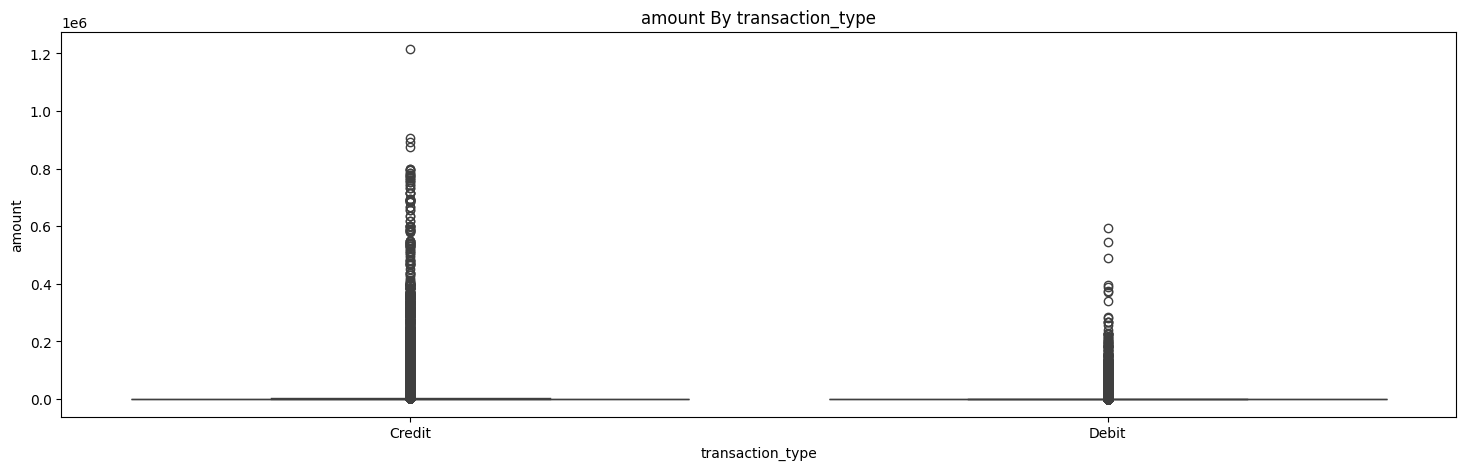


 Group Mean and Median of amount by transaction_type:
                         mean  median    count
transaction_type                              
Credit            2036.870827  720.89   610871
Debit              521.728511  120.00  1766298


<Figure size 1800x500 with 0 Axes>

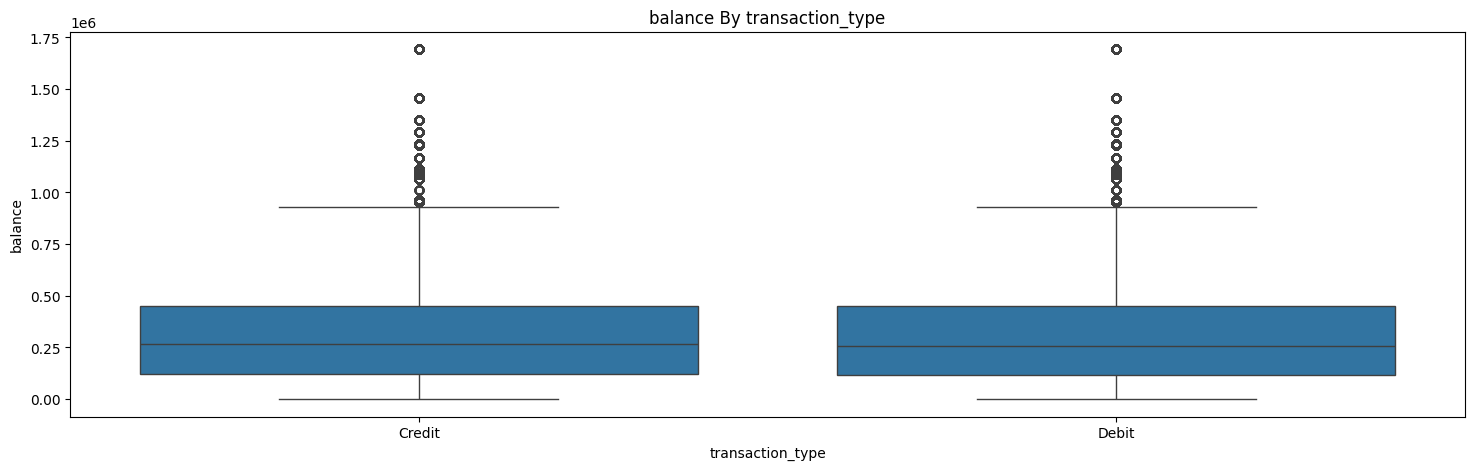


 Group Mean and Median of balance by transaction_type:
                           mean     median    count
transaction_type                                   
Credit            320774.117221  265967.07   610871
Debit             317567.569641  258865.31  1766298


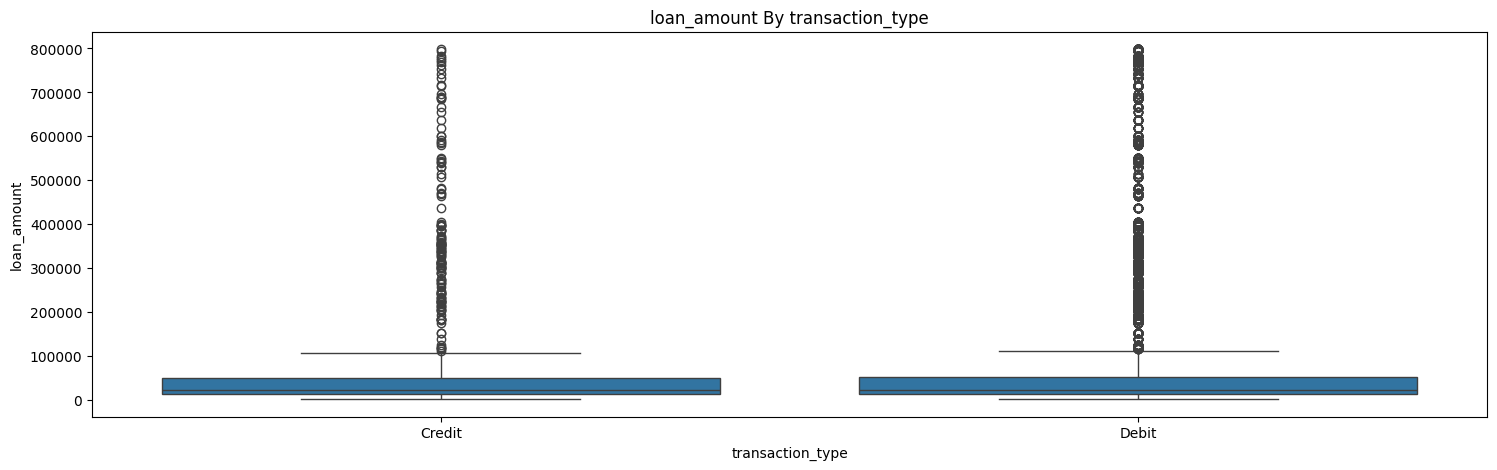


 Group Mean and Median of loan_amount by transaction_type:
                          mean    median  count
transaction_type                               
Credit            76234.810278  22844.58   1007
Debit             73321.246309  22632.69  30548


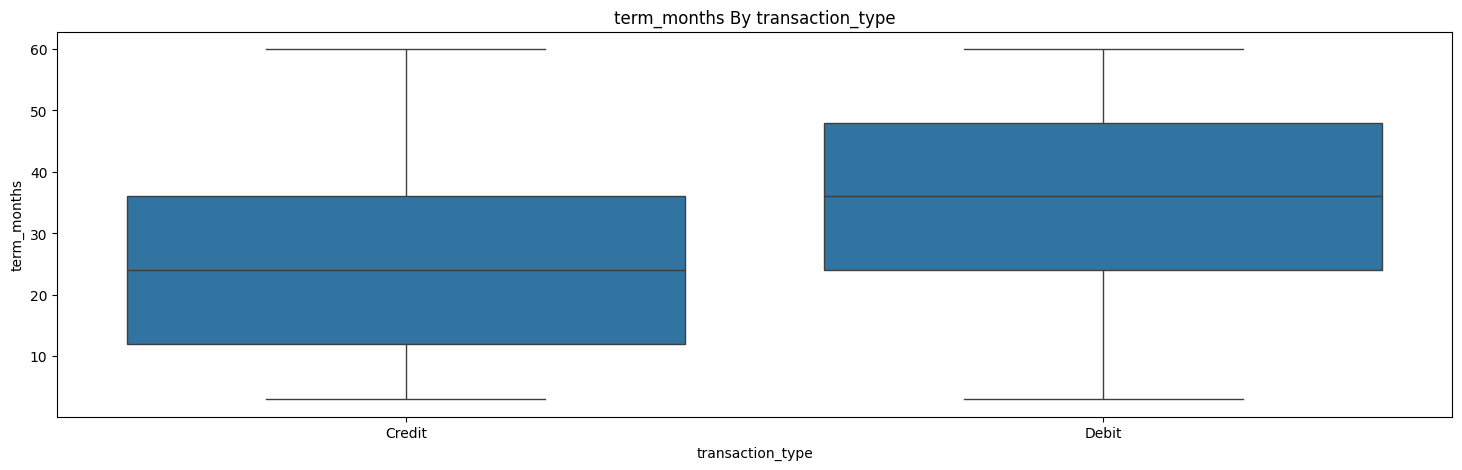


 Group Mean and Median of term_months by transaction_type:
                       mean  median  count
transaction_type                          
Credit            23.609871    24.0   2553
Debit             38.213423    36.0  31393


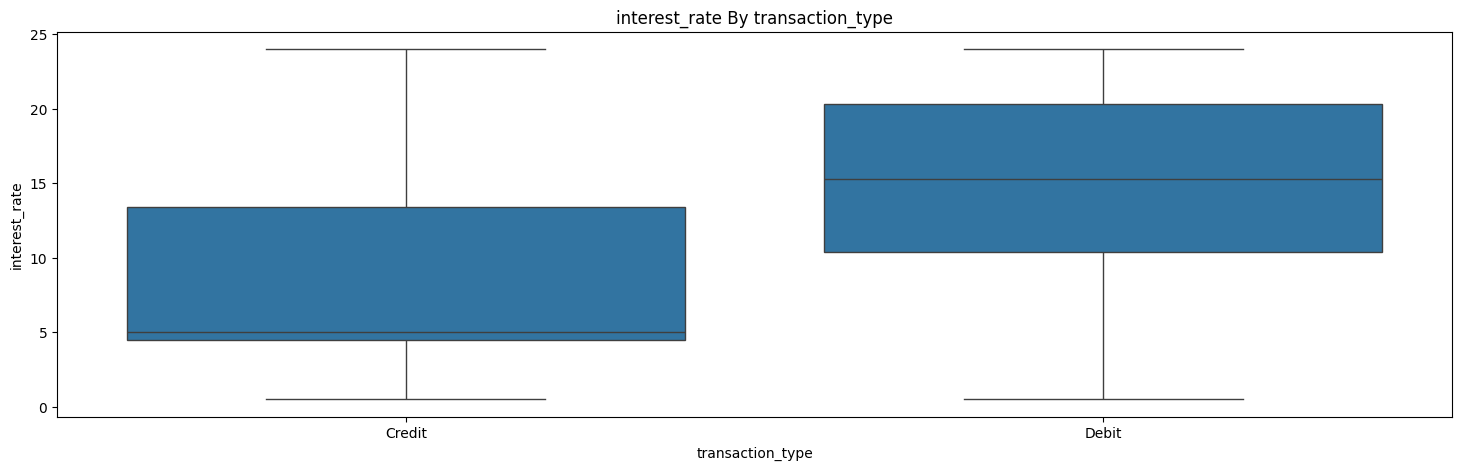


 Group Mean and Median of interest_rate by transaction_type:
                       mean  median  count
transaction_type                          
Credit             8.704857     5.0   2553
Debit             15.150671    15.3  31393


<Figure size 1800x500 with 0 Axes>

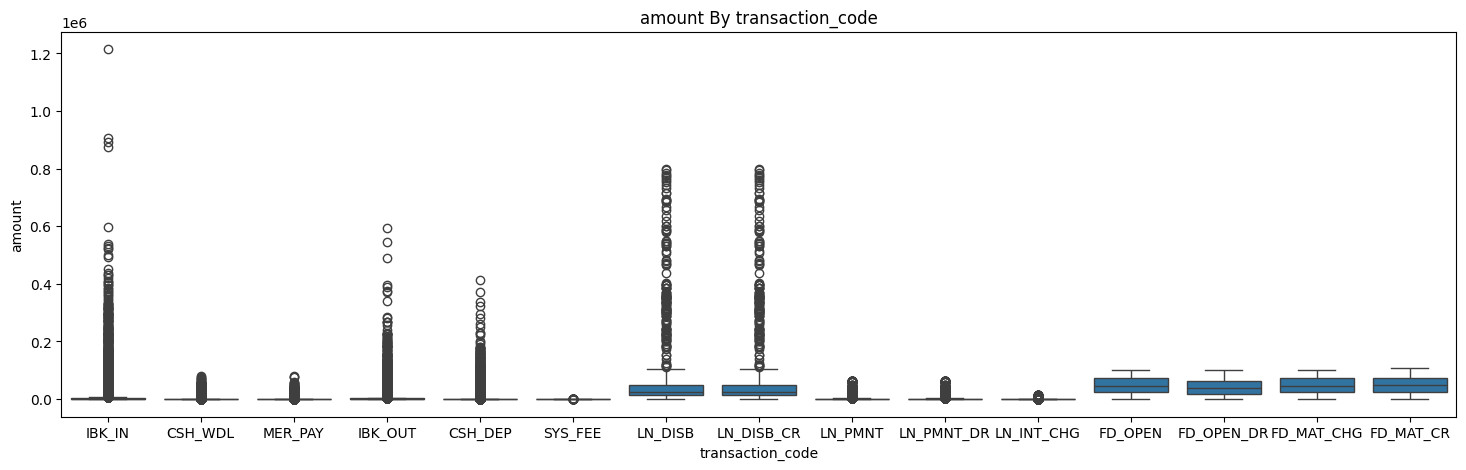


 Group Mean and Median of amount by transaction_code:
                          mean     median   count
transaction_code                                 
CSH_DEP             871.177855    480.000  371234
CSH_WDL             319.792223    180.000  490430
FD_MAT_CHG        48001.258497  46263.550     845
FD_MAT_CR         49552.739598  48144.160     845
FD_OPEN           48287.970931  46598.670    1546
FD_OPEN_DR        42251.613874  38318.445    1012
IBK_IN             2766.597669   1458.975  235232
IBK_OUT            1945.056868   1108.490  240805
LN_DISB           76234.810278  22844.580    1007
LN_DISB_CR        76234.810278  22844.580    1007
LN_INT_CHG          614.862892    187.445   15274
LN_PMNT            2467.818967    721.450   15274
LN_PMNT_DR         2467.818967    721.450   15274
MER_PAY             130.263310     61.520  983952
SYS_FEE              12.242532     12.040    3432


<Figure size 1800x500 with 0 Axes>

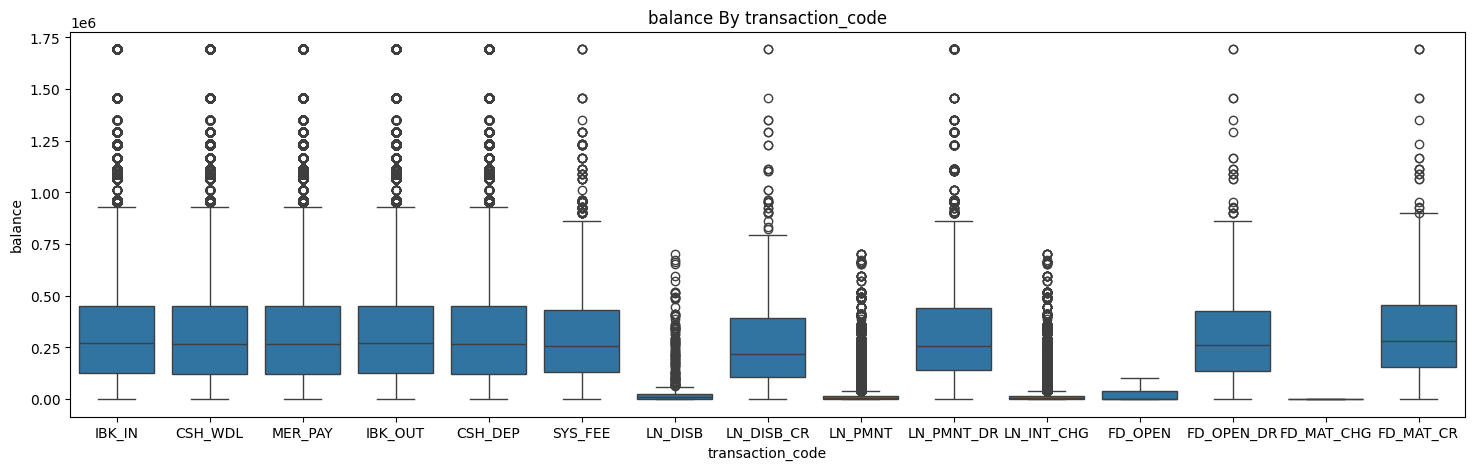


 Group Mean and Median of balance by transaction_code:
                           mean      median   count
transaction_code                                   
CSH_DEP           322518.047437  268814.950  371234
CSH_WDL           322980.791821  268814.950  490430
FD_MAT_CHG             0.000000       0.000     845
FD_MAT_CR         330170.329669  282362.330     845
FD_OPEN            22051.836759       0.000    1546
FD_OPEN_DR        304398.558883  261302.515    1012
IBK_IN            321353.487720  270732.060  235232
IBK_OUT           324359.770347  271664.870  240805
LN_DISB            38803.363505    9538.180    1007
LN_DISB_CR        275229.652284  217546.980    1007
LN_INT_CHG         23505.732695    4668.380   15274
LN_PMNT            23505.732695    4668.380   15274
LN_PMNT_DR        311772.579859  258865.310   15274
MER_PAY           322764.170479  268814.950  983952
SYS_FEE           302875.574041  255107.160    3432


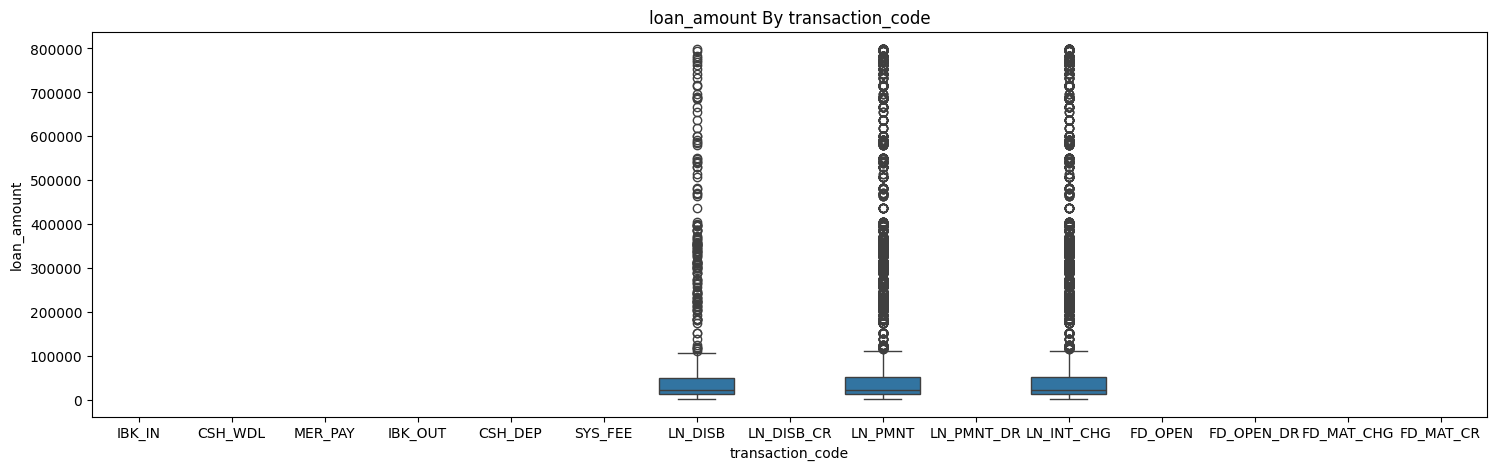


 Group Mean and Median of loan_amount by transaction_code:
                          mean    median  count
transaction_code                               
CSH_DEP                    NaN       NaN      0
CSH_WDL                    NaN       NaN      0
FD_MAT_CHG                 NaN       NaN      0
FD_MAT_CR                  NaN       NaN      0
FD_OPEN                    NaN       NaN      0
FD_OPEN_DR                 NaN       NaN      0
IBK_IN                     NaN       NaN      0
IBK_OUT                    NaN       NaN      0
LN_DISB           76234.810278  22844.58   1007
LN_DISB_CR                 NaN       NaN      0
LN_INT_CHG        73321.246309  22632.69  15274
LN_PMNT           73321.246309  22632.69  15274
LN_PMNT_DR                 NaN       NaN      0
MER_PAY                    NaN       NaN      0
SYS_FEE                    NaN       NaN      0


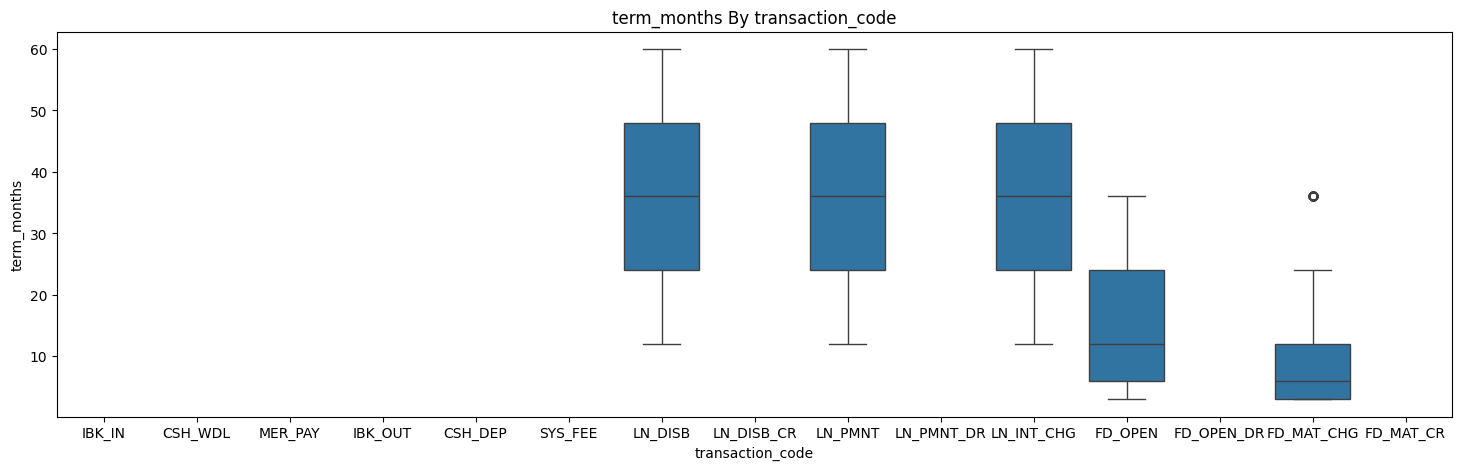


 Group Mean and Median of term_months by transaction_code:
                       mean  median  count
transaction_code                          
CSH_DEP                <NA>    <NA>      0
CSH_WDL                <NA>    <NA>      0
FD_MAT_CHG         10.55858     6.0    845
FD_MAT_CR              <NA>    <NA>      0
FD_OPEN           16.090556    12.0   1546
FD_OPEN_DR             <NA>    <NA>      0
IBK_IN                 <NA>    <NA>      0
IBK_OUT                <NA>    <NA>      0
LN_DISB           35.153923    36.0   1007
LN_DISB_CR             <NA>    <NA>      0
LN_INT_CHG        38.978395    36.0  15274
LN_PMNT           38.978395    36.0  15274
LN_PMNT_DR             <NA>    <NA>      0
MER_PAY                <NA>    <NA>      0
SYS_FEE                <NA>    <NA>      0


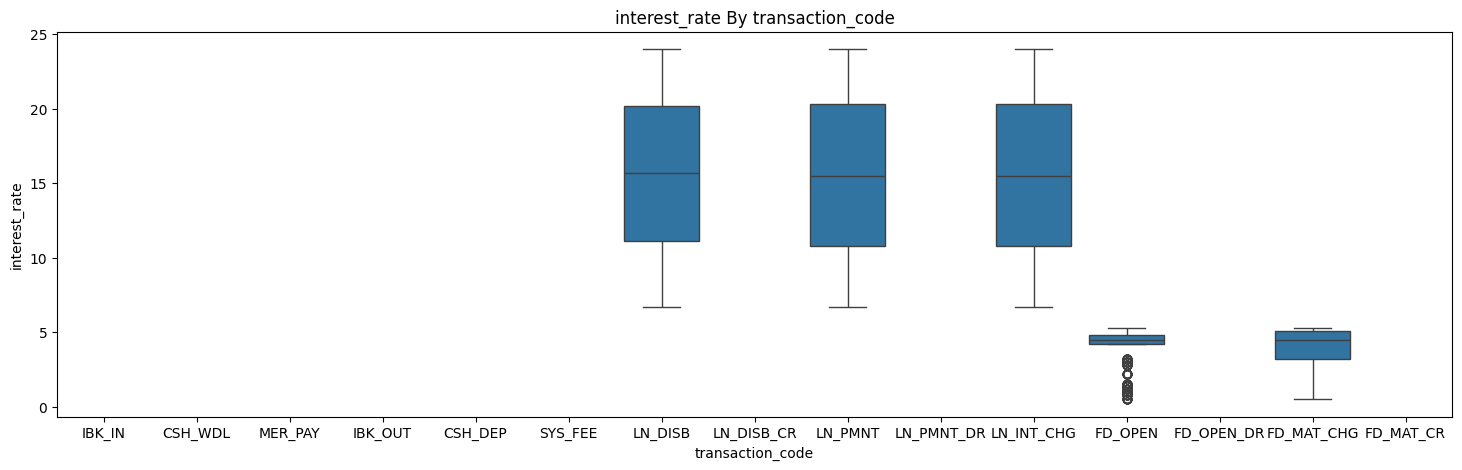


 Group Mean and Median of interest_rate by transaction_code:
                       mean  median  count
transaction_code                          
CSH_DEP                 NaN     NaN      0
CSH_WDL                 NaN     NaN      0
FD_MAT_CHG         3.967811     4.5    845
FD_MAT_CR               NaN     NaN      0
FD_OPEN            4.240944     4.5   1546
FD_OPEN_DR              NaN     NaN      0
IBK_IN                  NaN     NaN      0
IBK_OUT                 NaN     NaN      0
LN_DISB           15.558093    15.7   1007
LN_DISB_CR              NaN     NaN      0
LN_INT_CHG        15.460004    15.5  15274
LN_PMNT           15.460004    15.5  15274
LN_PMNT_DR              NaN     NaN      0
MER_PAY                 NaN     NaN      0
SYS_FEE                 NaN     NaN      0


<Figure size 1800x500 with 0 Axes>

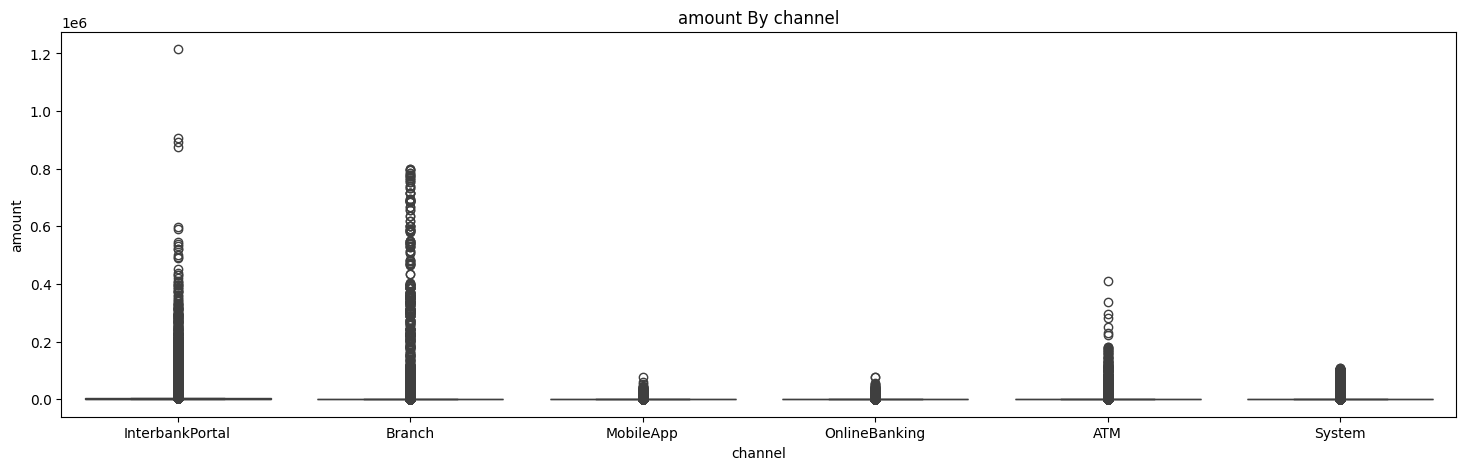


 Group Mean and Median of amount by channel:
                        mean    median   count
channel                                       
ATM               562.872702   280.000  430995
Branch           1253.758457   282.410  465789
InterbankPortal  2351.018349  1270.480  476037
MobileApp         130.233380    61.430  491964
OnlineBanking     130.293237    61.620  491988
System           4504.145939   155.905   20396


<Figure size 1800x500 with 0 Axes>

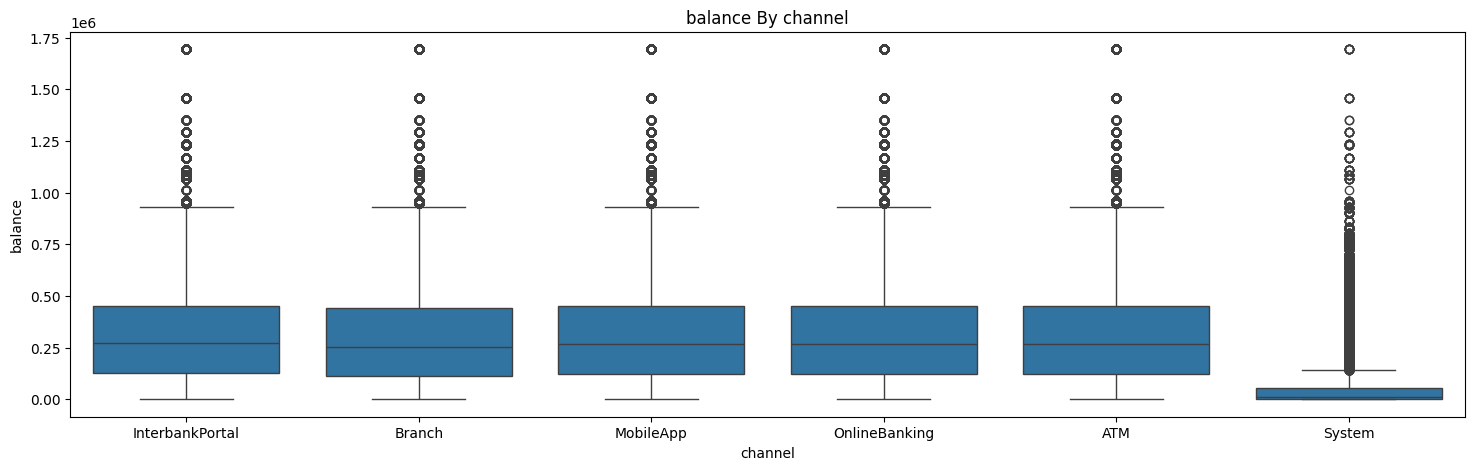


 Group Mean and Median of balance by channel:
                          mean     median   count
channel                                          
ATM              322939.210669  268814.95  430995
Branch           310705.845623  251741.81  465789
InterbankPortal  322874.226419  270732.06  476037
MobileApp        322716.626123  268814.95  491964
OnlineBanking    322811.712517  268814.95  491988
System            82246.002150    8658.95   20396


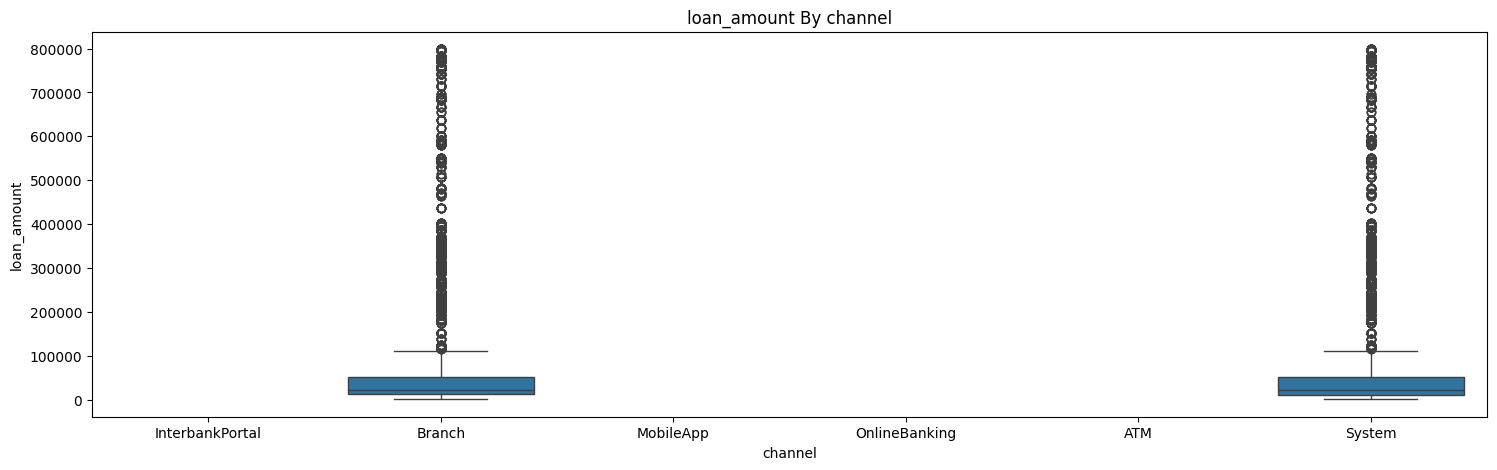


 Group Mean and Median of loan_amount by channel:
                         mean    median  count
channel                                       
ATM                       NaN       NaN      0
Branch           73501.453846  22632.69  16281
InterbankPortal           NaN       NaN      0
MobileApp                 NaN       NaN      0
OnlineBanking             NaN       NaN      0
System           73321.246309  22632.69  15274


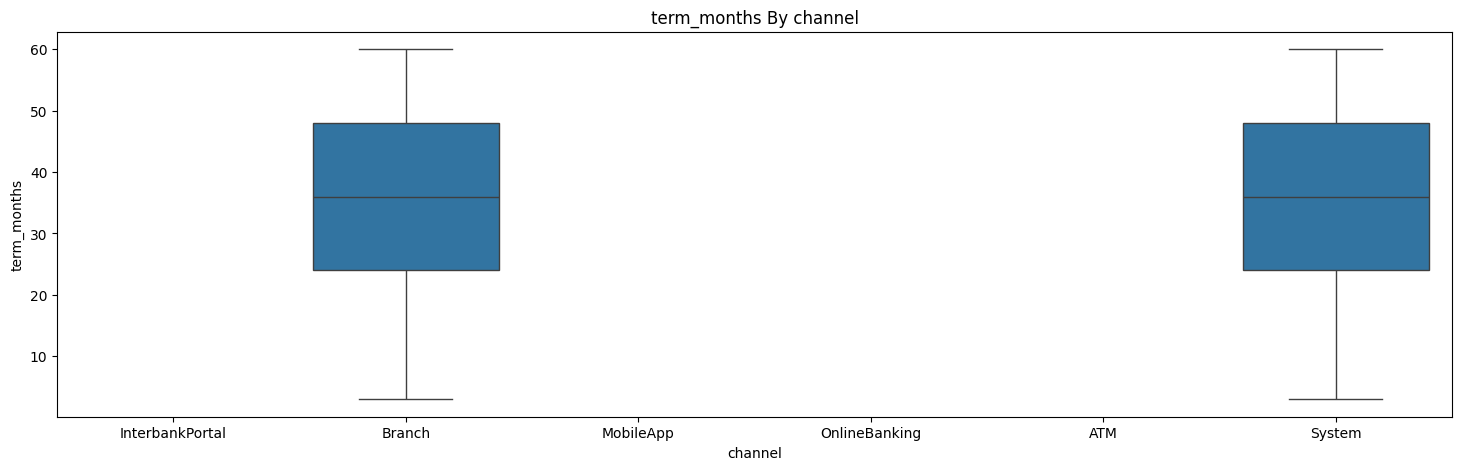


 Group Mean and Median of term_months by channel:
                      mean  median  count
channel                                  
ATM                   <NA>    <NA>      0
Branch           36.777472    36.0  17827
InterbankPortal       <NA>    <NA>      0
MobileApp             <NA>    <NA>      0
OnlineBanking         <NA>    <NA>      0
System           37.488554    36.0  16119


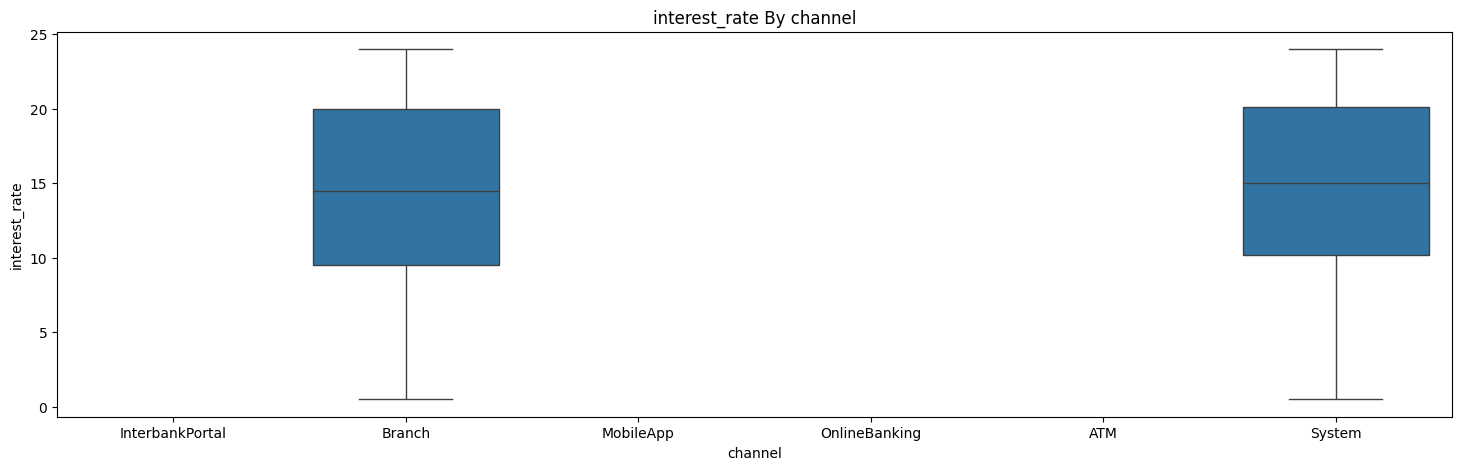


 Group Mean and Median of interest_rate by channel:
                      mean  median  count
channel                                  
ATM                    NaN     NaN      0
Branch           14.492601    14.5  17827
InterbankPortal        NaN     NaN      0
MobileApp              NaN     NaN      0
OnlineBanking          NaN     NaN      0
System           14.857553    15.0  16119


<Figure size 1800x500 with 0 Axes>

<Figure size 1800x500 with 0 Axes>

<Figure size 1800x500 with 0 Axes>

<Figure size 1800x500 with 0 Axes>

<Figure size 1800x500 with 0 Axes>

<Figure size 1800x500 with 0 Axes>

<Figure size 1800x500 with 0 Axes>

<Figure size 1800x500 with 0 Axes>

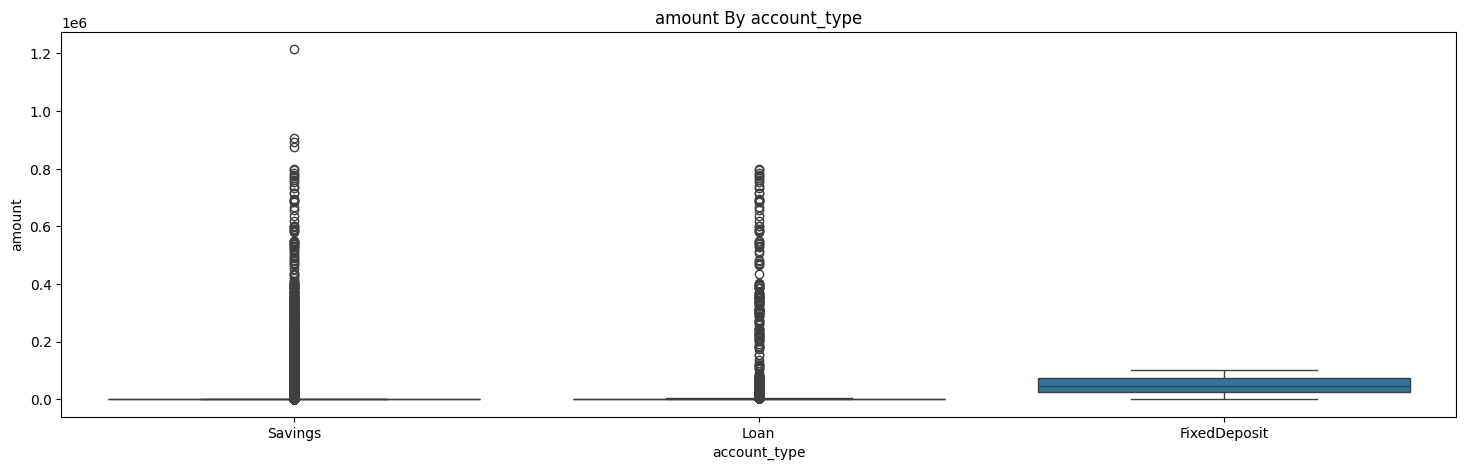


 Group Mean and Median of amount by account_type:
                      mean    median    count
account_type                                 
FixedDeposit  48186.644287  46480.65     2391
Loan           3924.998785    377.80    31555
Savings         822.254536    200.00  2343223


<Figure size 1800x500 with 0 Axes>

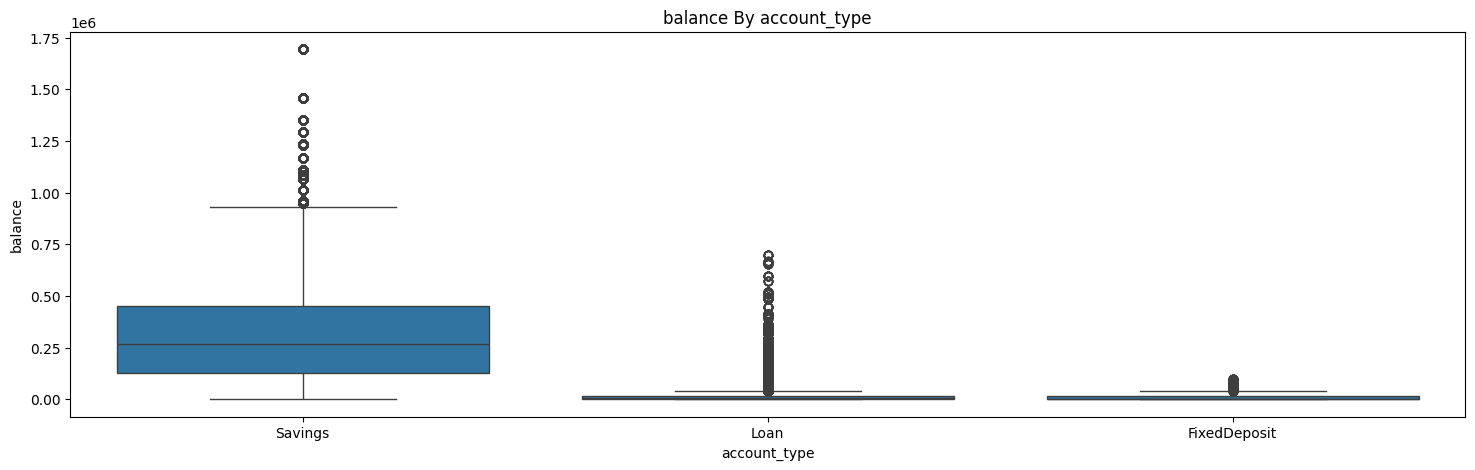


 Group Mean and Median of balance by account_type:
                       mean     median    count
account_type                                   
FixedDeposit   14258.527658       0.00     2391
Loan           23993.918853    4725.76    31555
Savings       322666.408034  268814.95  2343223


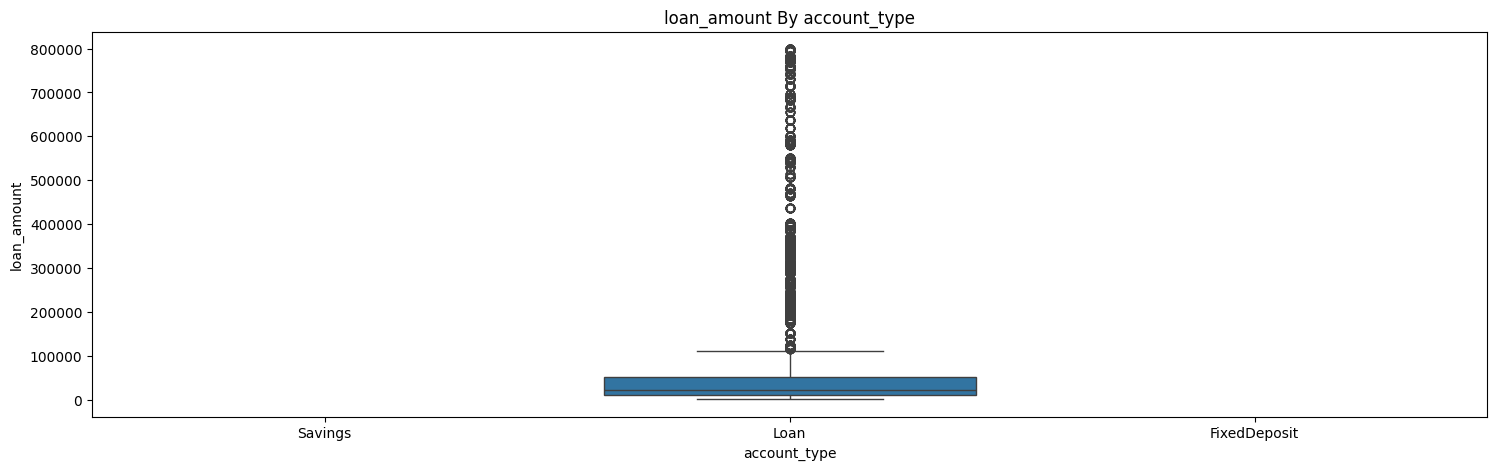


 Group Mean and Median of loan_amount by account_type:
                      mean    median  count
account_type                               
FixedDeposit           NaN       NaN      0
Loan          73414.225517  22632.69  31555
Savings                NaN       NaN      0


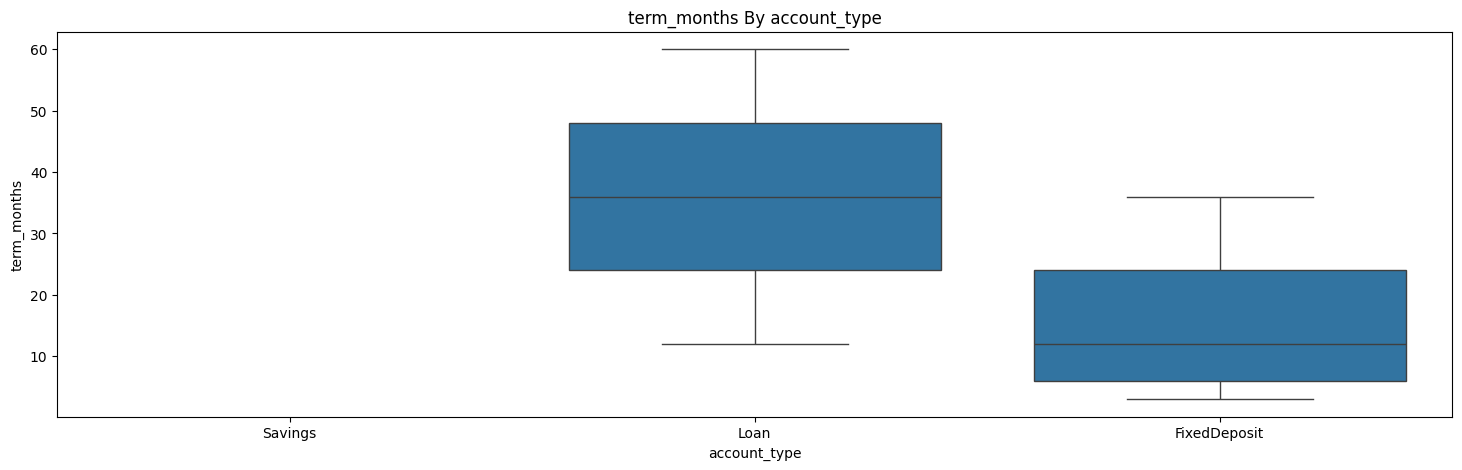


 Group Mean and Median of term_months by account_type:
                   mean  median  count
account_type                          
FixedDeposit  14.135508    12.0   2391
Loan          38.856346    36.0  31555
Savings            <NA>    <NA>      0


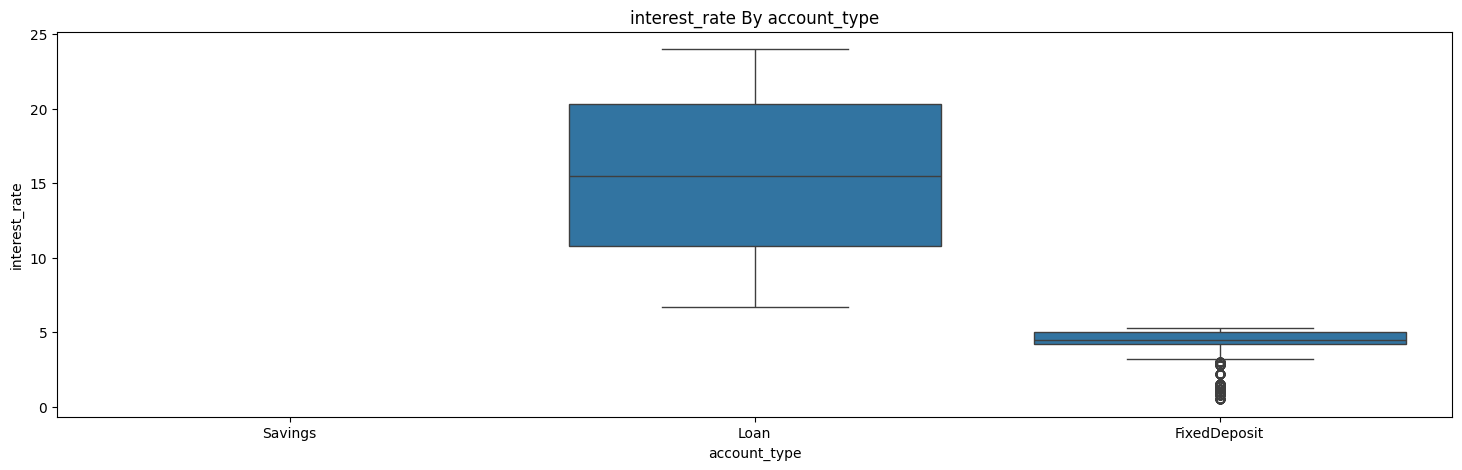


 Group Mean and Median of interest_rate by account_type:
                   mean  median  count
account_type                          
FixedDeposit   4.144417     4.5   2391
Loan          15.463134    15.5  31555
Savings             NaN     NaN      0


<Figure size 1800x500 with 0 Axes>

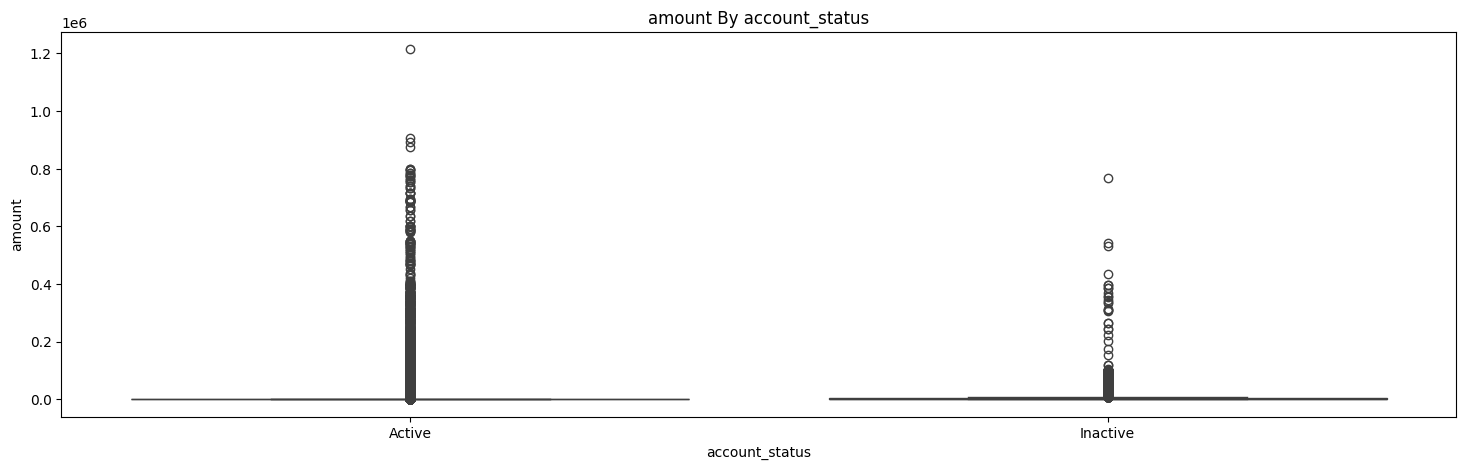


 Group Mean and Median of amount by account_status:
                       mean   median    count
account_status                               
Active           868.585385  200.000  2365679
Inactive        9660.499511  544.885    11490


<Figure size 1800x500 with 0 Axes>

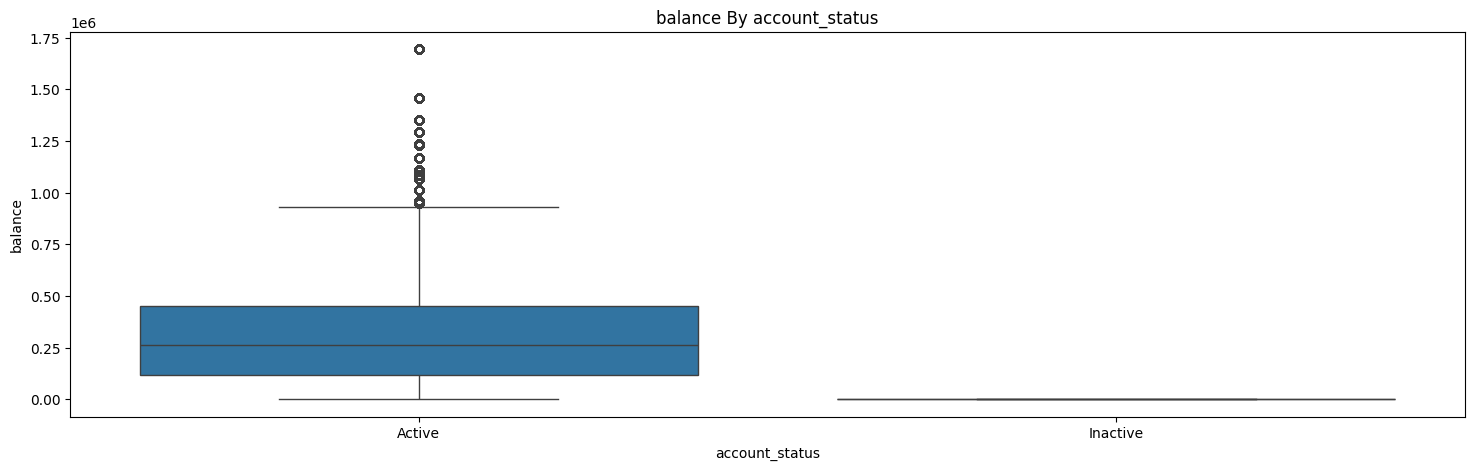


 Group Mean and Median of balance by account_status:
                         mean     median    count
account_status                                   
Active          319937.983506  263335.83  2365679
Inactive             0.000000       0.00    11490


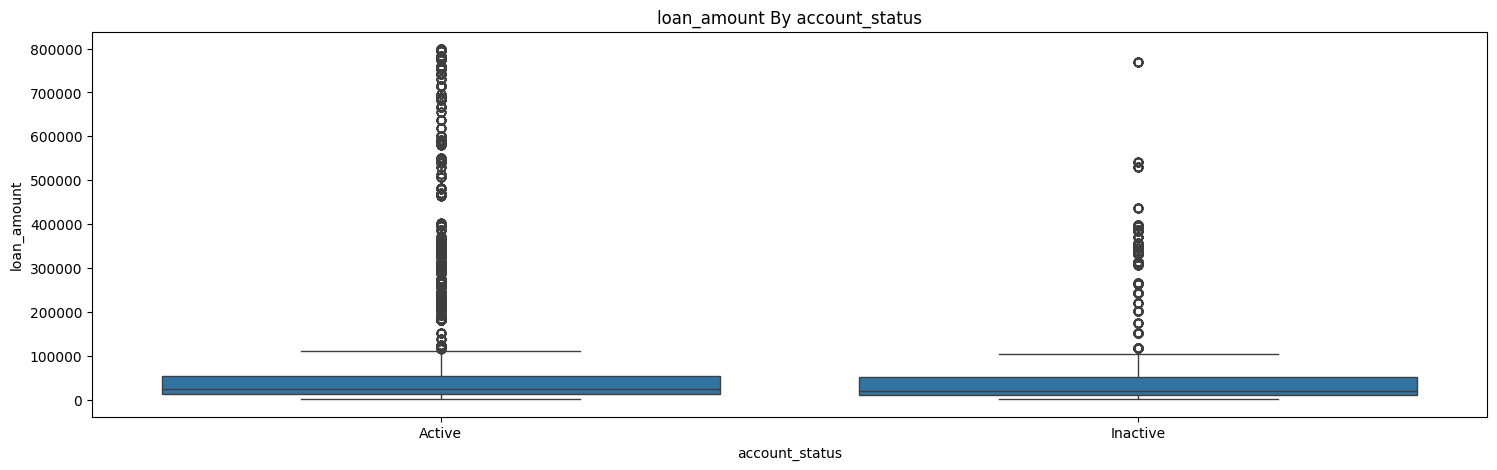


 Group Mean and Median of loan_amount by account_status:
                        mean    median  count
account_status                               
Active          79053.899588  24575.37  21755
Inactive        60894.724557  19171.23   9800


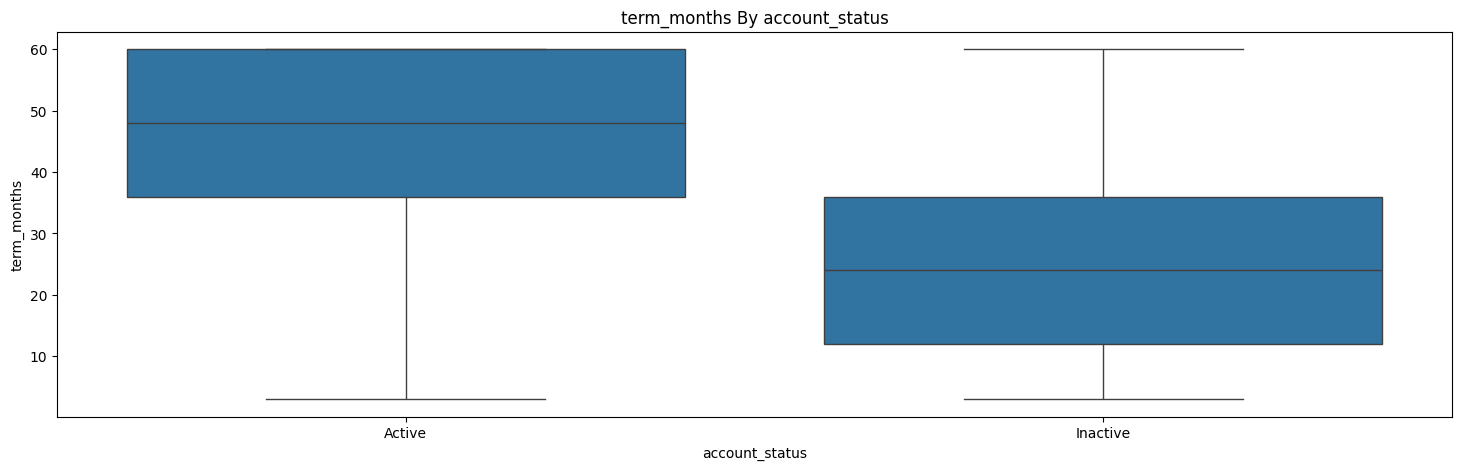


 Group Mean and Median of term_months by account_status:
                     mean  median  count
account_status                          
Active          42.952529    48.0  22456
Inactive        25.706527    24.0  11490


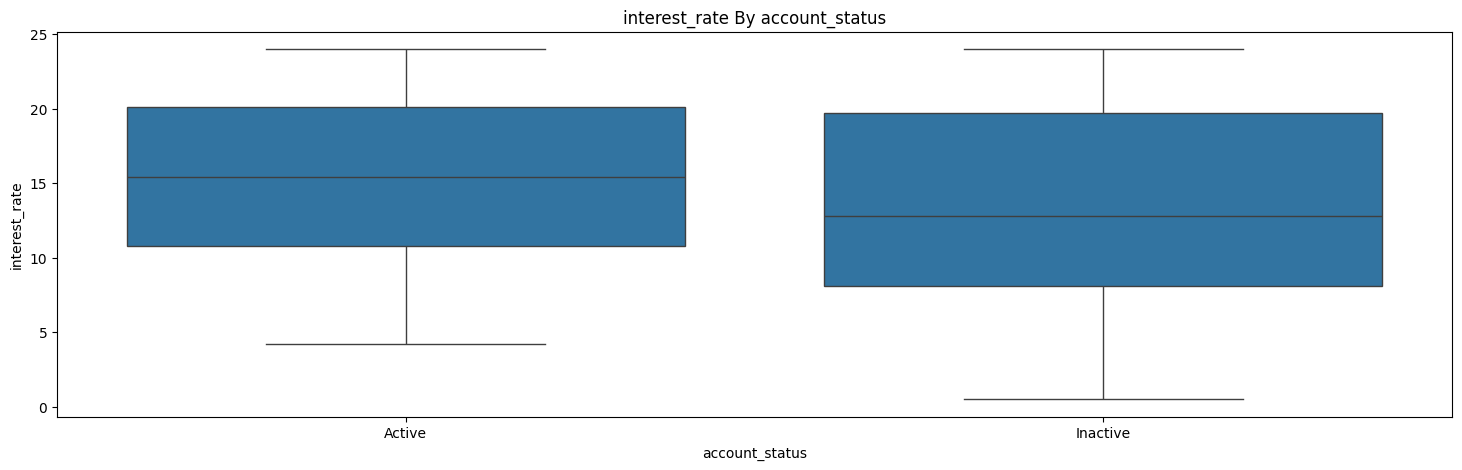


 Group Mean and Median of interest_rate by account_status:
                    mean  median  count
account_status                         
Active          15.23058    15.4  22456
Inactive        13.56228    12.8  11490


<Figure size 1800x500 with 0 Axes>

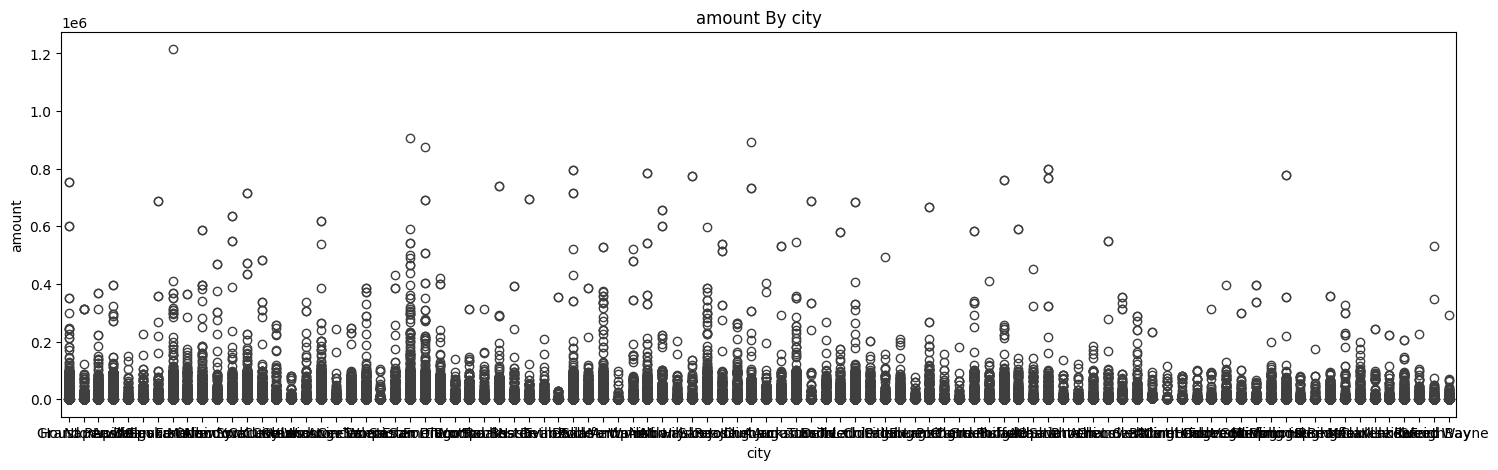


 Group Mean and Median of amount by city:
                       mean   median  count
city                                       
Akron           1014.973381  168.145  30184
Albany           943.499504  170.675  27412
Allentown        838.714982  154.030  18993
Arlington       1618.166616  220.000   1052
Athens           951.147693  186.655  13650
...                     ...      ...    ...
Vancouver       1076.591074  240.000  16384
Virginia Beach   796.170114  131.530   4211
Warren           897.085692  153.870  20329
Winston-Salem    941.294229  260.000   9401
Worcester        590.591716  100.000   4523

[94 rows x 3 columns]


<Figure size 1800x500 with 0 Axes>

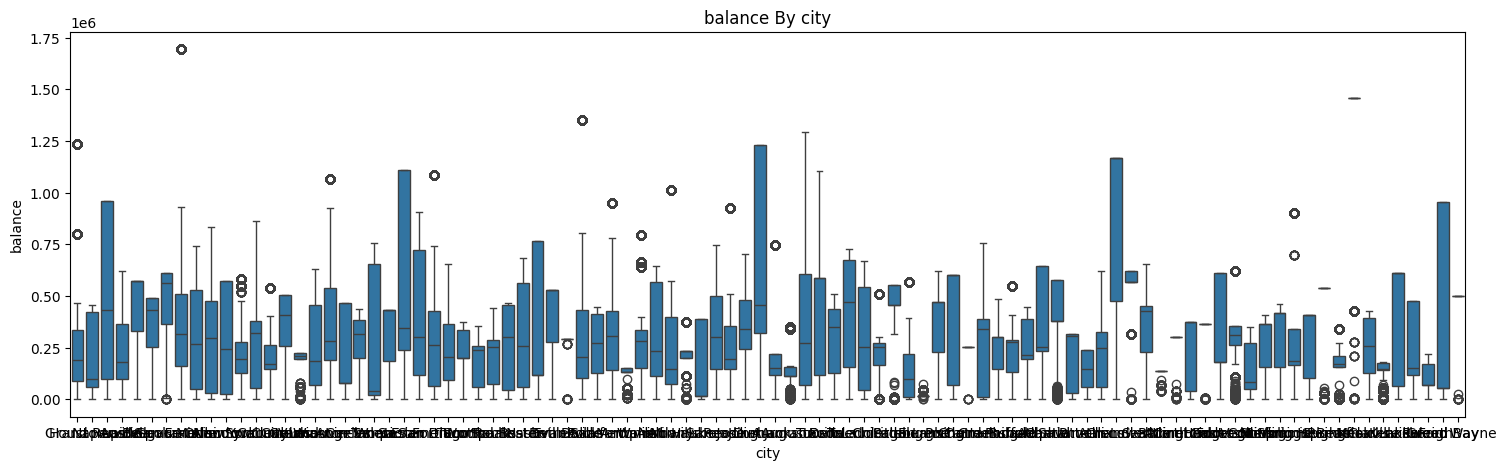


 Group Mean and Median of balance by city:
                         mean     median  count
city                                           
Akron           335541.981146  233826.69  30184
Albany          226055.983702  145004.13  27412
Allentown       244790.953363  244022.84  18993
Arlington       292903.302006  303347.24   1052
Athens          233046.977779  248207.50  13650
...                       ...        ...    ...
Vancouver       242983.307848  186694.74  16384
Virginia Beach  316259.761579  408854.96   4211
Warren          323428.792767  281651.28  20329
Winston-Salem   208936.427025   76391.54   9401
Worcester       303312.270040  432031.68   4523

[94 rows x 3 columns]


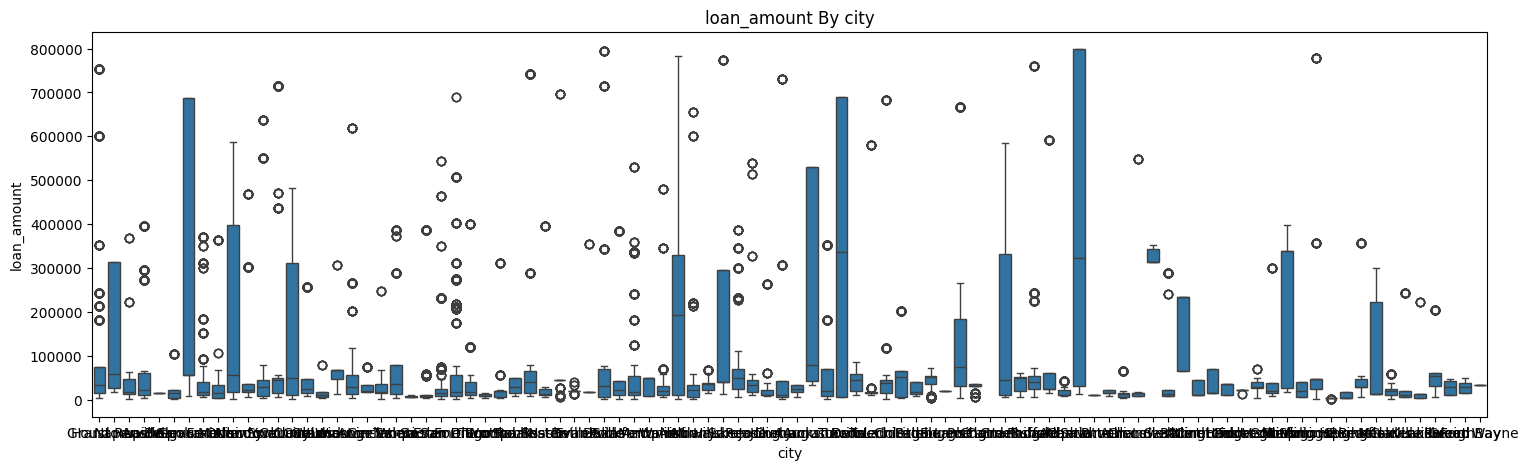


 Group Mean and Median of loan_amount by city:
                         mean     median  count
city                                           
Akron           236706.133598  191828.77    378
Albany           53495.384118   23099.38    510
Allentown        88455.590358   21843.31    335
Arlington        25920.340882   11515.81     34
Athens           17509.470913   13661.73    416
...                       ...        ...    ...
Vancouver        61519.250205   68744.48    244
Virginia Beach    3091.319286    3297.98    140
Warren           43468.532781   18994.84    392
Winston-Salem    31346.724032   19130.68    124
Worcester         7151.311830    6215.85    153

[94 rows x 3 columns]


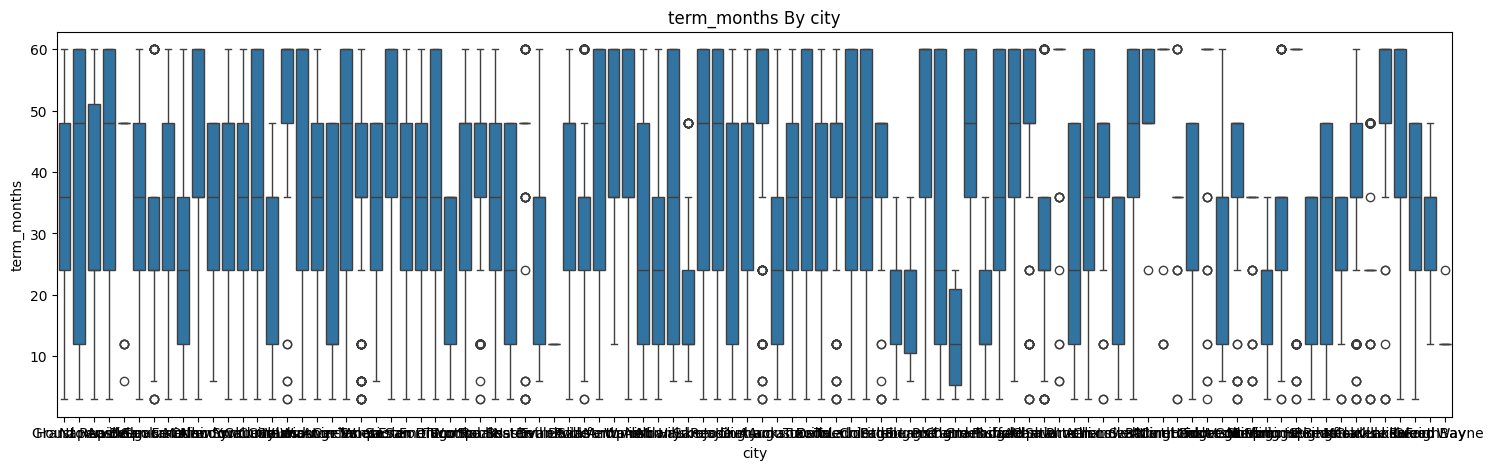


 Group Mean and Median of term_months by city:
                     mean  median  count
city                                    
Akron           33.086538    24.0    416
Albany           26.71978    24.0    546
Allentown        35.62069    36.0    348
Arlington       54.153846    60.0     39
Athens          40.802784    36.0    431
...                   ...     ...    ...
Vancouver       40.325581    60.0    258
Virginia Beach  49.520548    60.0    146
Warren          39.578049    36.0    410
Winston-Salem   27.664122    12.0    131
Worcester          33.525    36.0    160

[94 rows x 3 columns]


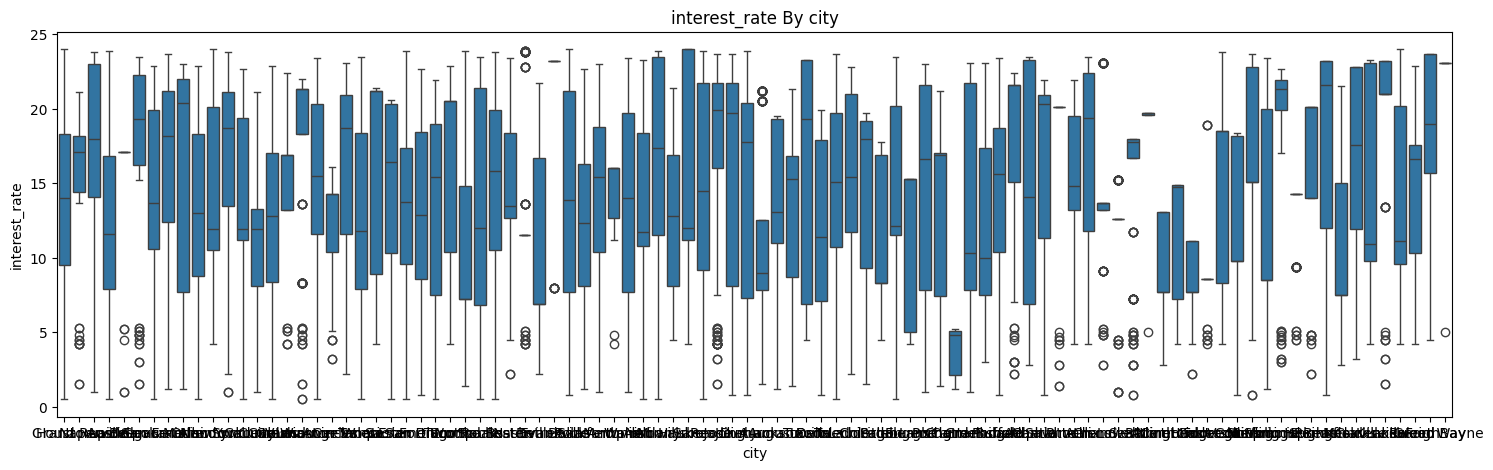


 Group Mean and Median of interest_rate by city:
                     mean  median  count
city                                    
Akron           13.651683    11.7    416
Albany          16.611172    17.4    546
Allentown       14.132184    11.9    348
Arlington        9.192308     7.7     39
Athens          17.517401    19.4    431
...                   ...     ...    ...
Vancouver       18.032558    21.3    258
Virginia Beach  13.070548    14.3    146
Warren          13.385610    14.0    410
Winston-Salem   12.278626    14.3    131
Worcester       16.238125    21.2    160

[94 rows x 3 columns]


<Figure size 1800x500 with 0 Axes>

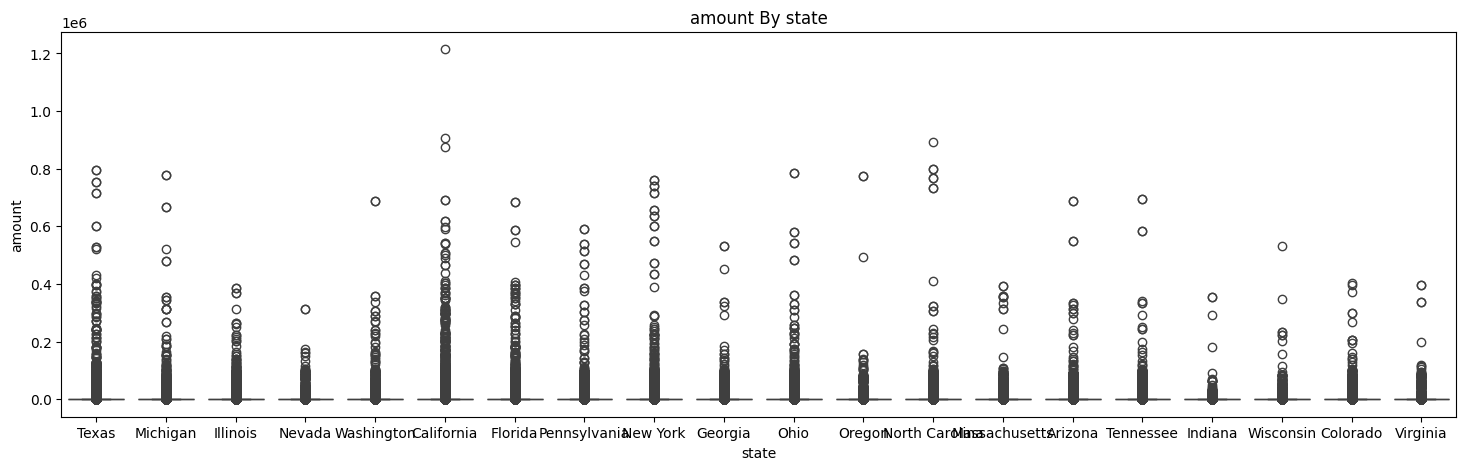


 Group Mean and Median of amount by state:
                       mean  median   count
state                                      
Arizona          855.157404  140.00   49810
California       883.924392  180.00  512460
Colorado         859.456685  193.29   65381
Florida          959.809074  220.00  237148
Georgia          937.492837  216.60   73171
Illinois         842.200006  180.00  121344
Indiana          737.942483  180.00   14963
Massachusetts    853.195062  180.00   55527
Michigan         911.415786  180.00   87333
Nevada           764.791690  180.00   41762
New York         996.763539  220.00  201850
North Carolina  1101.432081  260.00   75590
Ohio             896.361938  195.32  133687
Oregon           943.220980  231.12   42196
Pennsylvania     902.306778  200.00  120485
Tennessee        979.008476  201.52   63259
Texas            892.580432  200.00  345024
Virginia         856.589942  140.00   29465
Washington       853.076901  166.27   78900
Wisconsin       1093.922527  309

<Figure size 1800x500 with 0 Axes>

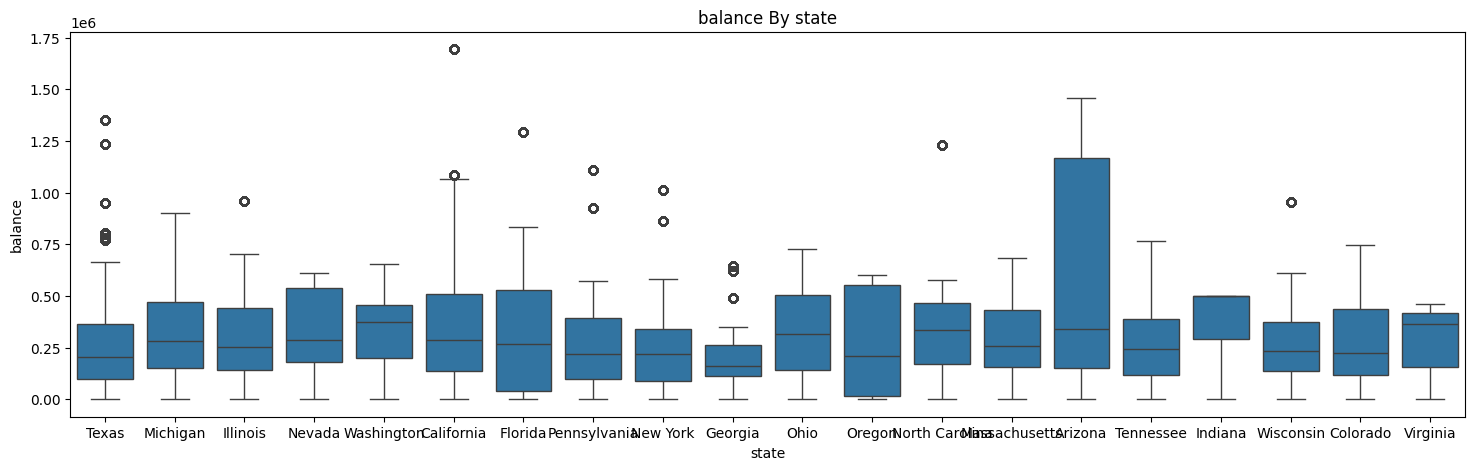


 Group Mean and Median of balance by state:
                         mean     median   count
state                                           
Arizona         649937.368531  338017.61   49810
California      355643.703316  287932.25  512460
Colorado        279659.568153  222212.79   65381
Florida         320785.934485  265411.36  237148
Georgia         200599.875006  160127.07   73171
Illinois        336825.236347  251619.75  121344
Indiana         416559.564347  498480.63   14963
Massachusetts   288589.170736  257488.28   55527
Michigan        326520.953173  281926.73   87333
Nevada          322001.757603  285477.21   41762
New York        244299.618540  221040.50  201850
North Carolina  427292.733675  334228.35   75590
Ohio            331871.154359  318028.07  133687
Oregon          258486.123273  210173.15   42196
Pennsylvania    316551.995393  220754.91  120485
Tennessee       251737.290165  243373.62   63259
Texas           269079.995206  205477.72  345024
Virginia        293825.4

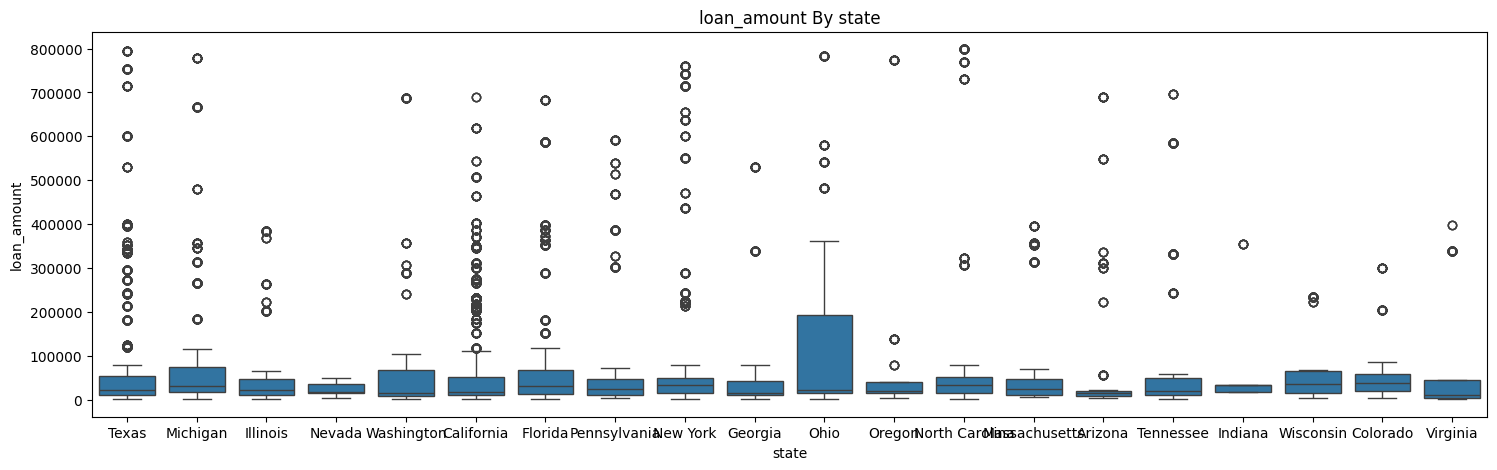


 Group Mean and Median of loan_amount by state:
                         mean    median  count
state                                         
Arizona          52672.195677  15941.31    650
California       53116.551822  18469.94   6651
Colorado         48930.511444  39118.35    720
Florida          80423.647310  30998.28   2963
Georgia          44296.600828  14119.79   1220
Illinois         47576.668343  21655.48   1545
Indiana          65429.916842  33543.13     57
Massachusetts    76810.960238  24558.86    798
Michigan         97914.893855  31536.99   1424
Nevada           23696.061429  17113.55    525
New York         93829.866167  32661.35   3084
North Carolina  120620.595426  32849.02    903
Ohio            119414.561756  21138.76   1566
Oregon           55750.610826  18897.79    557
Pennsylvania     69609.782509  24457.15   1610
Tennessee       103320.703962  20765.95   1007
Texas            78884.440278  22380.33   4427
Virginia         81837.696531  11515.81    343
Washington 

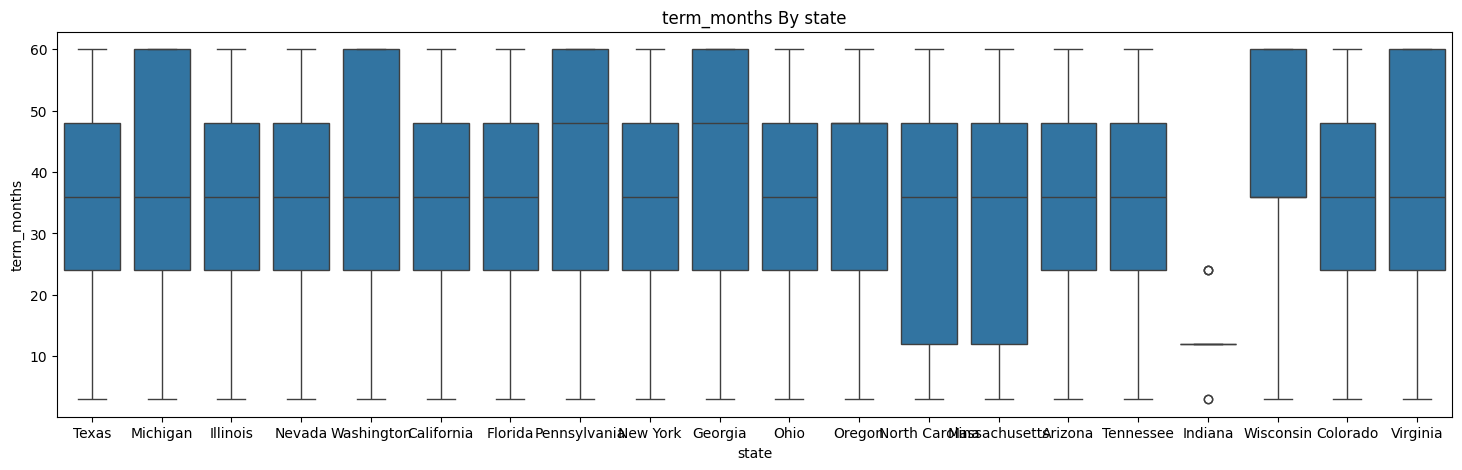


 Group Mean and Median of term_months by state:
                     mean  median  count
state                                   
Arizona         37.434599    36.0    711
California      36.522989    36.0   7199
Colorado        36.735777    36.0    791
Florida         36.823382    36.0   3199
Georgia         40.821182    48.0   1303
Illinois        35.260843    36.0   1660
Indiana          12.28125    12.0     64
Massachusetts    30.69555    36.0    854
Michigan        40.705726    36.0   1502
Nevada          38.722913    36.0    563
New York         35.14844    36.0   3301
North Carolina  30.594484    36.0    979
Ohio            37.113879    36.0   1686
Oregon          38.583051    48.0    590
Pennsylvania    39.756507    48.0   1729
Tennessee        38.31793    36.0   1082
Texas           38.854614    36.0   4746
Virginia        38.543307    36.0    381
Washington      36.786408    36.0   1030
Wisconsin       40.541667    36.0    576


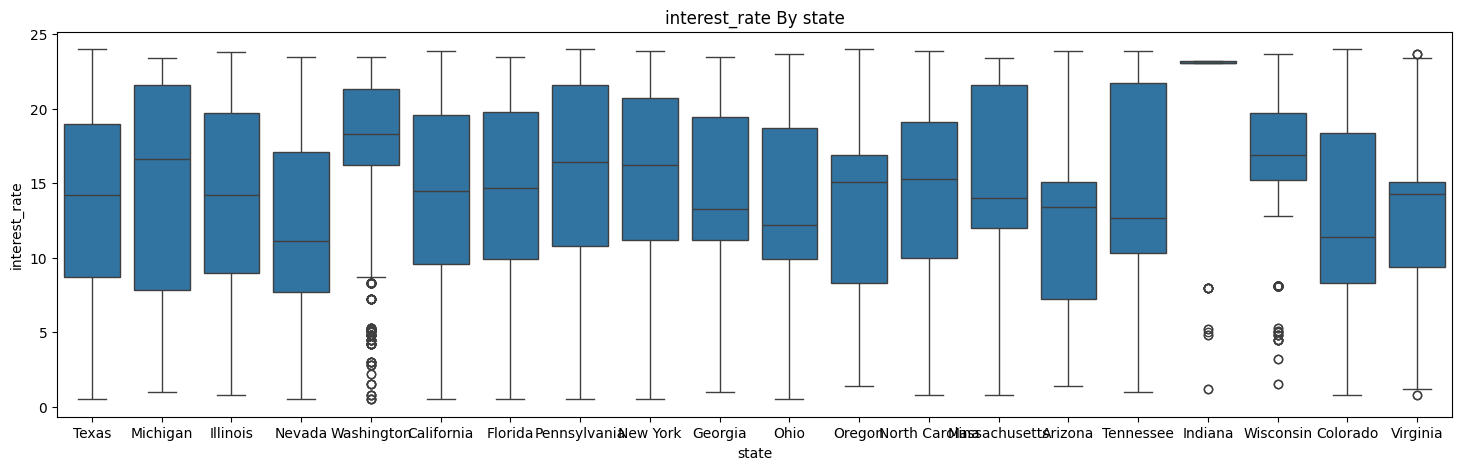


 Group Mean and Median of interest_rate by state:
                     mean  median  count
state                                   
Arizona         13.117581    13.4    711
California      14.522753    14.5   7199
Colorado        12.964096    11.4    791
Florida         14.471397    14.7   3199
Georgia         14.745434    13.3   1303
Illinois        14.325843    14.2   1660
Indiana         19.389063    23.1     64
Massachusetts   15.752225    14.0    854
Michigan        15.132290    16.6   1502
Nevada          12.341563    11.1    563
New York        15.596183    16.2   3301
North Carolina  14.752196    15.3    979
Ohio            13.794306    12.2   1686
Oregon          13.437627    15.1    590
Pennsylvania    15.930769    16.4   1729
Tennessee       14.965342    12.7   1082
Texas           13.998230    14.2   4746
Virginia        13.760630    14.3    381
Washington      17.240583    18.3   1030
Wisconsin       16.971701    16.9    576


In [21]:
for cat_col in df:
    for num_col in num_df:
        plt.figure(figsize=(18, 5))
        if 'id' in cat_col.lower() or 'id' in num_col.lower():
            continue
        sns.boxplot(x = df[cat_col], y = num_df[num_col])
        plt.title(f'{num_col} By {cat_col}')
        plt.show()

        print(f"\n Group Mean and Median of {num_col} by {cat_col}:")
        print(full_df.groupby(cat_col)[num_col].agg(['mean', 'median', 'count']))

### Annova Test

### Amount vs Transaction Type

In [23]:
from scipy import stats
annova_res = stats.f_oneway(*[group['amount'].values for name, group in full_df.groupby('transaction_type')])
print('Annova Test for Amount across Transaction Types:')
print('F-Statistics:', round(annova_res.statistic, 3), 'P-Value:', round(annova_res.pvalue, 3))
if annova_res.pvalue < 0.05:
    print("There is a statistically significant difference in mean transaction amount.")
else:
    print("There is no statistically significant difference in mean transaction amount.")


Annova Test for Amount across Transaction Types:
F-Statistics: 24465.812 P-Value: 0.0
There is a statistically significant difference in mean transaction amount.


### Amount vs Transaction Code

In [24]:
annova_res = stats.f_oneway(*[group['amount'].values for name, group in full_df.groupby('transaction_code')])
print('Annova Test for Amount across Transaction Codes:')
print('F-Statistics:', round(annova_res.statistic, 3), 'P-Value:', round(annova_res.pvalue, 3))
if annova_res.pvalue < 0.05:
    print("There is a statistically significant difference in mean transaction amount.")
else:
    print("There is no statistically significant difference in mean transaction amount.")

Annova Test for Amount across Transaction Codes:
F-Statistics: 47658.172 P-Value: 0.0
There is a statistically significant difference in mean transaction amount.


### Amount vs Account Type

In [25]:
annova_res = stats.f_oneway(*[group['amount'].values for name, group in full_df.groupby('account_type')])
print('Annova Test for Amount across Account Types:')
print('F-Statistics:', round(annova_res.statistic, 3), 'P-Value:', round(annova_res.pvalue, 3))
if annova_res.pvalue < 0.05:
    print("There is a statistically significant difference in mean transaction amount.")
else:
    print("There is no statistically significant difference in mean transaction amount.")

Annova Test for Amount across Account Types:
F-Statistics: 69480.635 P-Value: 0.0
There is a statistically significant difference in mean transaction amount.


### Category - Category

### Chic Square Test

### Account Type vs Transaction Type


Contigency Table (Account Type vs Transaction Type):
 transaction_type  Credit    Debit
account_type                     
FixedDeposit        1546      845
Loan                1007    30548
Savings           608318  1734905


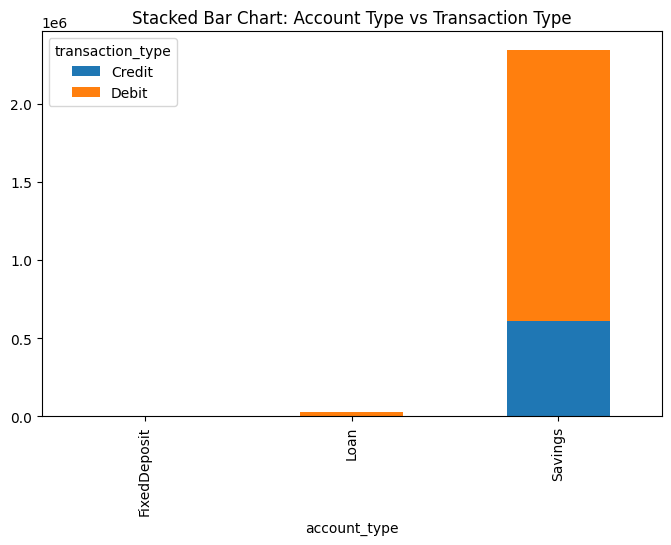


Chic_Square Test Result:
chic2 = 10357.015, p-value = 0.000, Degree of Freedom = 2.000
Significant relationship (reject null hypothesis)


In [26]:
from scipy.stats import chi2_contingency

contigency = pd.crosstab(full_df['account_type'], full_df['transaction_type'])
print('\nContigency Table (Account Type vs Transaction Type):\n', contigency)

contigency.plot(kind = 'bar', stacked = True, figsize=(8, 5))
plt.title('Stacked Bar Chart: Account Type vs Transaction Type')
plt.show()

chic2, p, dof, expected = chi2_contingency(contigency)
print('\nChic_Square Test Result:')
print(f'chic2 = {chic2:.3f}, p-value = {p:.3f}, Degree of Freedom = {dof:.3f}')

if p < 0.05:
    print("Significant relationship (reject null hypothesis)")
else:
    print("No Significant relationship (fail to reject null hypothesis)")

### Account Type vs Transaction Codes


Contigency Table (Account Type vs Transaction Code):
 transaction_code  CSH_DEP  CSH_WDL  FD_MAT_CHG  FD_MAT_CR  FD_OPEN  \
account_type                                                         
FixedDeposit            0        0         845          0     1546   
Loan                    0        0           0          0        0   
Savings            371234   490430           0        845        0   

transaction_code  FD_OPEN_DR  IBK_IN  IBK_OUT  LN_DISB  LN_DISB_CR  \
account_type                                                         
FixedDeposit               0       0        0        0           0   
Loan                       0       0        0     1007           0   
Savings                 1012  235232   240805        0        1007   

transaction_code  LN_INT_CHG  LN_PMNT  LN_PMNT_DR  MER_PAY  SYS_FEE  
account_type                                                         
FixedDeposit               0        0           0        0        0  
Loan                   15274    1

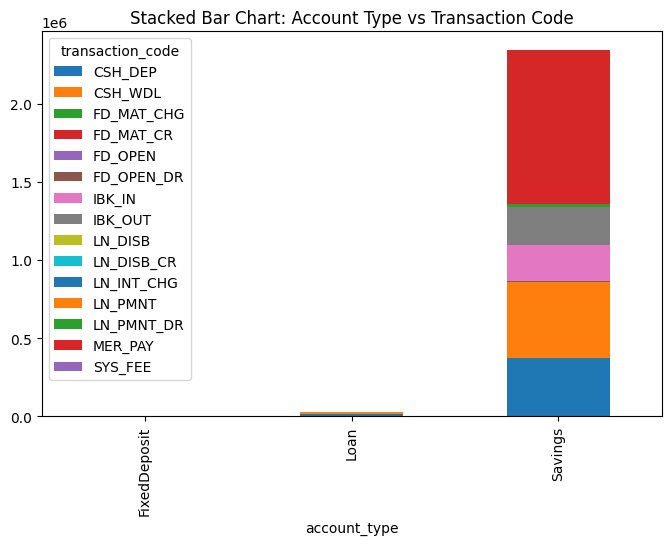


Chic_Square Test Result:
chic2 = 4754338.000, p-value = 0.000, Degree of Freedom = 28.000
Significant relationship (reject null hypothesis)


In [27]:
contigency = pd.crosstab(full_df['account_type'], full_df['transaction_code'])
print('\nContigency Table (Account Type vs Transaction Code):\n', contigency)

contigency.plot(kind = 'bar', stacked = True, figsize=(8, 5))
plt.title('Stacked Bar Chart: Account Type vs Transaction Code')
plt.show()

chic2, p, dof, expected = chi2_contingency(contigency)
print('\nChic_Square Test Result:')
print(f'chic2 = {chic2:.3f}, p-value = {p:.3f}, Degree of Freedom = {dof:.3f}')

if p < 0.05:
    print("Significant relationship (reject null hypothesis)")
else:
    print("No Significant relationship (fail to reject null hypothesis)")

### Account Type vs Account Status


Contigency Table (Account Type vs Account Status):
 account_status   Active  Inactive
account_type                     
FixedDeposit        701      1690
Loan              21755      9800
Savings         2343223         0


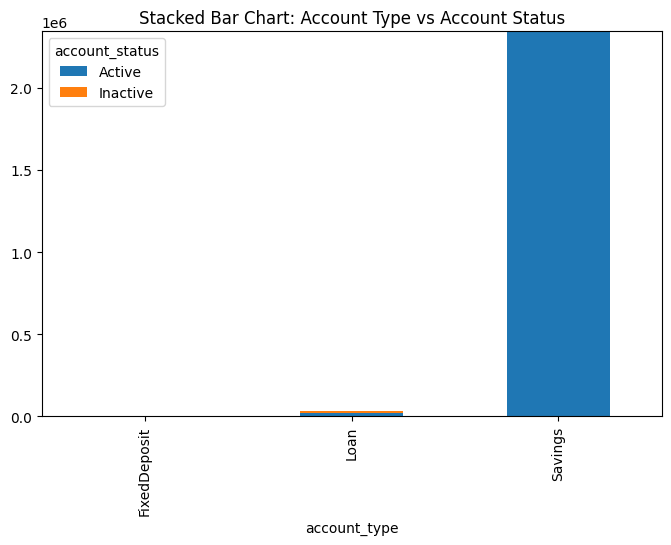


Chic_Square Test Result:
chic2 = 869533.590, p-value = 0.000, Degree of Freedom = 2.000
Significant relationship (reject null hypothesis)


In [28]:
contigency = pd.crosstab(full_df['account_type'], full_df['account_status'])
print('\nContigency Table (Account Type vs Account Status):\n', contigency)

contigency.plot(kind = 'bar', stacked = True, figsize=(8, 5))
plt.title('Stacked Bar Chart: Account Type vs Account Status')
plt.show()

chic2, p, dof, expected = chi2_contingency(contigency)
print('\nChic_Square Test Result:')
print(f'chic2 = {chic2:.3f}, p-value = {p:.3f}, Degree of Freedom = {dof:.3f}')

if p < 0.05:
    print("Significant relationship (reject null hypothesis)")
else:
    print("No Significant relationship (fail to reject null hypothesis)")

### ACF - Time Series Analysis

In [29]:
daily_amount = account_transactions.groupby(account_transactions['created_time'].dt.date)['amount'].sum()

In [30]:
daily_amount_diff = daily_amount.diff().dropna()

<Figure size 640x480 with 0 Axes>

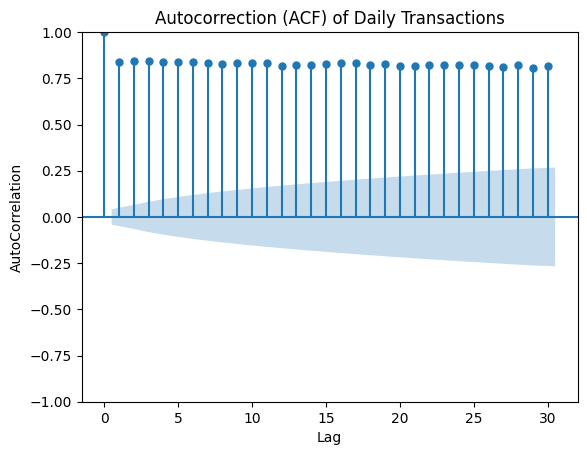

In [31]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure()
plot_acf(daily_amount, lags=30)
plt.title("Autocorrection (ACF) of Daily Transactions")
plt.xlabel('Lag')
plt.ylabel('AutoCorrelation')
plt.show()

<Figure size 640x480 with 0 Axes>

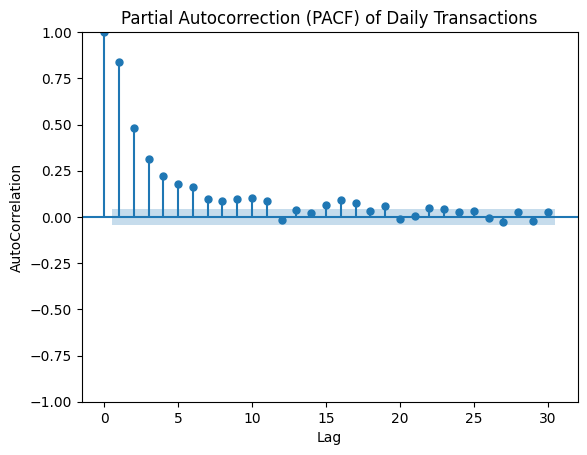

In [32]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure()
plot_pacf(daily_amount, lags=30)
plt.title("Partial Autocorrection (PACF) of Daily Transactions")
plt.xlabel('Lag')
plt.ylabel('AutoCorrelation')
plt.show()

In [33]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(daily_amount_diff)

print("ADF Statistics:", result[0])
print("p-value:", round(result[1], 10))

ADF Statistics: -15.27183045825773
p-value: 0.0


### Multivariate Analysis

### Loan Analysis

               loan_amount  term_months  interest_rate
loan_amount       1.000000    -0.002939      -0.051195
term_months      -0.002939     1.000000       0.475985
interest_rate    -0.051195     0.475985       1.000000


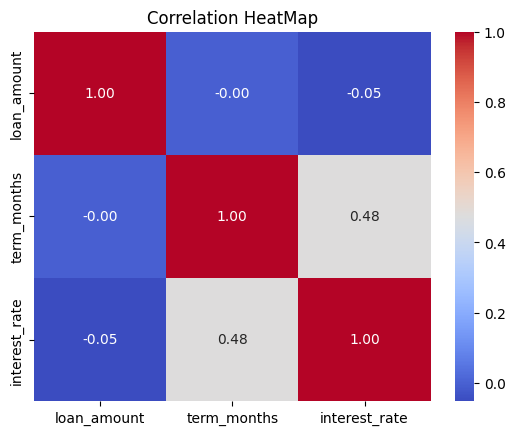

In [34]:
numeric_df = bank_accounts[['loan_amount', 'term_months', 'interest_rate']]
correlation = numeric_df.corr()
print(correlation)

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt = '.2f')
plt.title('Correlation HeatMap')
plt.show()

### Transaction Analysis

In [35]:
transaction_analysis = account_transactions.groupby(['transaction_type', 'channel'])['amount'].agg(['count', 'sum', 'mean', 'median']).reset_index()
display(transaction_analysis)

,transaction_type,channel,count,sum,mean,median
0,Credit,ATM,186083,1.642111e+08,882.461482,480.000
1,Credit,Branch,188711,3.873899e+08,2052.820826,480.000
2,Credit,InterbankPortal,235232,6.507923e+08,2766.597669,1458.975
3,Credit,System,845,4.187206e+07,49552.739598,48144.160
4,Debit,ATM,244912,7.838424e+07,320.050630,180.000
5,Debit,Branch,277078,1.965970e+08,709.536762,200.000
6,Debit,InterbankPortal,240805,4.683794e+08,1945.056868,1108.490
7,Debit,MobileApp,491964,6.407013e+07,130.233380,61.430
8,Debit,OnlineBanking,491988,6.410271e+07,130.293237,61.620
9,Debit,System,19551,4.999450e+07,2557.132403,141.700


### Customer + Account Analysis

In [37]:
full_df.groupby(['state', 'account_type', 'account_status'])['balance'].agg(['count', 'sum', 'mean', 'median']).reset_index()

,state,account_type,account_status,count,sum,mean,median
0,Arizona,FixedDeposit,Active,13,6.452623e+05,49635.559231,47494.77
1,Arizona,FixedDeposit,Inactive,48,0.000000e+00,0.000000,0.00
2,Arizona,Loan,Active,455,2.313665e+07,50849.771407,7691.71
3,Arizona,Loan,Inactive,195,0.000000e+00,0.000000,0.00
4,Arizona,Savings,Active,49099,3.234960e+10,658864.710447,353871.67
...,...,...,...,...,...,...,...
95,Wisconsin,FixedDeposit,Active,7,3.265559e+05,46650.837143,38316.14
96,Wisconsin,FixedDeposit,Inactive,14,0.000000e+00,0.000000,0.00
97,Wisconsin,Loan,Active,407,1.143200e+07,28088.440393,9732.56
98,Wisconsin,Loan,Inactive,148,0.000000e+00,0.000000,0.00
